# RQ1 — Chi è il pivot strutturale di ogni semifinalista?

## Obiettivo

Questa notebook implementa la prima research question del progetto:
**identificare il giocatore strutturalmente più importante in ogni rete di 
passaggio delle quattro semifinaliste del Mondiale 2022** (Argentina, Francia, 
Croazia, Marocco).

"Importante" in network science non ha un significato unico. Utilizziamo
sei definizioni diverse di centralità, ciascuna delle quali cattura un aspetto
diverso del ruolo di un giocatore nella rete. I giocatori su cui queste
definizioni **non concordano** sono il risultato più interessante dell'analisi.

## Struttura del notebook

1. Setup e importazioni
2. Caricamento dati StatsBomb
3. Costruzione della rete di passaggio
4. Calcolo delle sei centralità
5. Correlazioni di Spearman tra le misure
6. Identificazione dei profili strutturali (Terminal / Broker / Metronome)
7. Null model — verifica statistica
8. Visualizzazioni
9. Analisi aggregata sulle quattro semifinaliste

## 1. Setup e importazioni

Importiamo le librerie necessarie:

- `statsbombpy` — accesso ai dati open di StatsBomb direttamente in Python
- `networkx` — costruzione e analisi delle reti
- `pandas` / `numpy` — manipolazione dati
- `matplotlib` / `seaborn` — visualizzazioni
- `scipy` — correlazioni di Spearman
- `mplsoccer` — disegno del campo da calcio

In [1]:
import warnings
# Non sopprimiamo TUTTO: nascondiamo solo il rumore noto (deprecation, future,
# UserWarning di mplsoccer/statsbombpy). RuntimeWarning (NaN, mancata
# convergenza) resta visibile di proposito.
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
from scipy.stats import spearmanr
from statsbombpy import sb
from mplsoccer import Pitch

# Configurazione globale
COMPETITION_ID = 43    # FIFA World Cup
SEASON_ID      = 106   # edizione 2022
SEMIFINALISTS  = ["Argentina", "France", "Croatia", "Morocco"]
# Soglia di inclusione di un giocatore nella rete aggregata di torneo.
# Minuti stimati da Starting XI (+90 per ogni titolare) corretti dalle
# sostituzioni (chi esce perde 90-minuto; chi entra guadagna 90-minuto).
MIN_MINUTES    = 30

# Palette colori per le squadre e per i reparti
TEAM_COLORS = {
    "Argentina": "#75AADB",
    "France":    "#002395",
    "Croatia":   "#FF0000",
    "Morocco":   "#006233",
}

LINE_COLORS = {
    "GK":      "#FFD700",
    "DEF":     "#2196F3",
    "MID":     "#4CAF50",
    "ATT":     "#F44336",
    "Unknown": "#999999",
}

print("✓ Setup completato")


✓ Setup completato


## 2. Caricamento dati StatsBomb

StatsBomb mette a disposizione gratuitamente i dati event-level del Mondiale 2022.
Ogni evento rappresenta un'azione sul campo (passaggio, tiro, conduzione, ecc.)
con timestamp, coordinate x/y sul campo (120×80 metri), e metadati specifici
per il tipo di evento.
Per questa analisi ci interessano solo gli eventi di tipo **Pass** con
`pass_outcome` nullo, che in StatsBomb indica un passaggio **completato**.

- `pass_outcome` assente → passaggio completato ✓  
- `pass_outcome` presente ("Incomplete", "Out", ecc.) → passaggio fallito ✗

Iniziamo caricando la lista di tutte le 64 partite del torneo e identificando
le partite giocate da ciascuna delle quattro semifinaliste.

In [2]:
# Carica la lista di tutte le partite del Mondiale 2022
matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f"Totale partite nel dataset: {len(matches)}")
print(f"Colonne disponibili: {matches.columns.tolist()}\n")

# Per ogni semifinalista, mostra le partite giocate
for team in SEMIFINALISTS:
    team_matches = matches[
        (matches["home_team"] == team) |
        (matches["away_team"] == team)
    ]
    print(f"{'─'*50}")
    print(f"{team}: {len(team_matches)} partite")
    for _, m in team_matches.iterrows():
        print(f"  [{m['match_id']}] {m['home_team']} vs {m['away_team']} — {m['competition_stage']}")

Totale partite nel dataset: 64
Colonne disponibili: ['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nickname', 'away_manager_dob', 'away_ma

## 3. Esplorazione della struttura degli eventi

Prima di costruire la rete, esploriamo la struttura di un singolo file di eventi
usando la **finale Argentina–Francia** come caso pilota.

Ogni file di eventi contiene tutte le azioni di una partita in ordine cronologico.
Vogliamo capire:
- Quanti eventi ci sono per partita
- Quanti sono passaggi completati
- Come sono strutturati i campi `player`, `pass_recipient`, `location`

Questo passaggio esplorativo è fondamentale prima di costruire qualsiasi rete:
conoscere i dati evita errori di interpretazione nelle analisi successive.

In [3]:
# Identifica il match_id della finale
finale_row = matches[matches["competition_stage"] == "Final"]
FINALE_ID = finale_row["match_id"].values[0]
print(f"Finale: {finale_row['home_team'].values[0]} vs "
      f"{finale_row['away_team'].values[0]} (match_id = {FINALE_ID})\n")

# Carica tutti gli eventi della finale
events_finale = sb.events(match_id=FINALE_ID)
print(f"Totale eventi nella partita: {len(events_finale)}")
print(f"\nDistribuzione per tipo di evento:")
print(events_finale["type"].value_counts().head(10))

Finale: Argentina vs France (match_id = 3869685)

Totale eventi nella partita: 4407

Distribuzione per tipo di evento:
type
Pass              1263
Ball Receipt*     1114
Carry              940
Pressure           361
Ball Recovery      115
Duel                98
Dribble             54
Block               50
Foul Committed      48
Clearance           45
Name: count, dtype: int64


In [4]:
# Filtra solo i passaggi e guarda la struttura
passes_raw = events_finale[events_finale["type"] == "Pass"].copy()

print(f"Totale passaggi (tutti):      {len(passes_raw)}")
print(f"Passaggi completati:          {passes_raw['pass_outcome'].isna().sum()}")
print(f"Passaggi falliti/incompleti:  {passes_raw['pass_outcome'].notna().sum()}")

print(f"\nEsempio di un passaggio completato:")
esempio = passes_raw[passes_raw["pass_outcome"].isna()].iloc[0]
print(f"  Giocatore:    {esempio['player']}")
print(f"  Ricevitore:   {esempio['pass_recipient']}")
print(f"  Squadra:      {esempio['team']}")
print(f"  Da:           {esempio['location']}")
print(f"  A:            {esempio['pass_end_location']}")

Totale passaggi (tutti):      1263
Passaggi completati:          994
Passaggi falliti/incompleti:  269

Esempio di un passaggio completato:
  Giocatore:    Antoine Griezmann
  Ricevitore:   Aurélien Djani Tchouaméni
  Squadra:      France
  Da:           [61.0, 40.1]
  A:            [48.0, 43.2]


## 4. Costruzione della rete di passaggio

Costruiamo la rete di passaggio per l'Argentina nella finale come caso pilota.
La rete è un **grafo diretto e pesato** dove:

- **Nodi** = giocatori
- **Archi** = direzione del passaggio (da chi passa → a chi riceve)
- **Peso dell'arco** = numero di passaggi completati tra quella coppia

### La convenzione della distanza: perché 1/peso

Le misure di betweenness e closeness centrality si basano sui **cammini più corti**
nella rete. Un algoritmo di cammino più corto cerca il percorso con la **somma
minima** dei pesi degli archi.

Nel nostro caso vogliamo che due giocatori che si scambiano molti passaggi siano
considerati **vicini**. Ma se usassimo il peso direttamente, un peso alto
significherebbe distanza alta — l'opposto di quello che vogliamo.

Soluzione: definiamo `distanza = 1 / peso`. Così:
- 20 passaggi tra A e B → distanza = 0.05 (vicini)
- 2 passaggi tra C e D  → distanza = 0.50 (lontani)

Questo è il bug più comune nella letteratura sulle reti di passaggio (Peña & 
Touchette, 2012) e viene corretto esplicitamente qui.

In [5]:
def build_passing_network(team_name, events_df):
    """
    Costruisce la rete di passaggio di una squadra da un DataFrame di eventi.
    
    Parametri
    ----------
    team_name : str
        Nome della squadra (come appare in StatsBomb)
    events_df : DataFrame
        Tutti gli eventi della partita
    
    Ritorna
    -------
    G : nx.DiGraph
        Grafo diretto e pesato con attributi 'weight' e 'distance' sugli archi
    passes_df : DataFrame
        DataFrame dei passaggi completati con coordinate
    """
    
    # Filtra: solo passaggi completati della squadra
    passes = events_df[
        (events_df["type"] == "Pass") &
        (events_df["team"] == team_name) &
        (events_df["pass_outcome"].isna())
    ].copy()
    
    # Estrai coordinate
    passes["x_start"] = passes["location"].apply(
        lambda l: l[0] if isinstance(l, list) else np.nan
    )
    passes["y_start"] = passes["location"].apply(
        lambda l: l[1] if isinstance(l, list) else np.nan
    )
    passes["x_end"] = passes["pass_end_location"].apply(
        lambda l: l[0] if isinstance(l, list) else np.nan
    )
    passes["y_end"] = passes["pass_end_location"].apply(
        lambda l: l[1] if isinstance(l, list) else np.nan
    )
    
    passes_clean = passes[
        ["player", "pass_recipient", "x_start", "y_start", "x_end", "y_end"]
    ].dropna(subset=["player", "pass_recipient"]).copy()
    passes_clean.columns = ["passer", "recipient", "x_start", "y_start", "x_end", "y_end"]
    
    # Conta i passaggi per ogni coppia (passer → recipient)
    edge_weights = (
        passes_clean
        .groupby(["passer", "recipient"])
        .size()
        .reset_index(name="weight")
    )
    
    # Calcola la posizione media di ogni giocatore sul campo
    avg_pos = (
        passes_clean
        .groupby("passer")[["x_start", "y_start"]]
        .mean()
        .rename(columns={"x_start": "avg_x", "y_start": "avg_y"})
    )
    
    # Costruisci il grafo
    G = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        G.add_edge(
            row["passer"],
            row["recipient"],
            weight=row["weight"],
            distance=1.0 / row["weight"]   # convenzione fondamentale
        )
    
    # Aggiungi posizione media come attributo del nodo
    for node in G.nodes():
        if node in avg_pos.index:
            G.nodes[node]["avg_x"] = avg_pos.loc[node, "avg_x"]
            G.nodes[node]["avg_y"] = avg_pos.loc[node, "avg_y"]
        else:
            G.nodes[node]["avg_x"] = 60.0
            G.nodes[node]["avg_y"] = 40.0
    
    return G, passes_clean


# Test sulla finale dell'Argentina
G_arg_finale, passes_arg_finale = build_passing_network("Argentina", events_finale)

print(f"Rete Argentina (finale):")
print(f"  Nodi (giocatori):  {G_arg_finale.number_of_nodes()}")
print(f"  Archi (coppie):    {G_arg_finale.number_of_edges()}")
print(f"  Passaggi totali:   {sum(d['weight'] for _,_,d in G_arg_finale.edges(data=True))}")

Rete Argentina (finale):
  Nodi (giocatori):  17
  Archi (coppie):    129
  Passaggi totali:   560


## 5. Calcolo delle sei centralità

Calcoliamo le sei misure di centralità per ogni giocatore nella rete.
Ogni misura risponde a una domanda diversa:

| Misura | Domanda | Distanza usata |
|--------|---------|----------------|
| **In-Degree pesato** | Quanti passaggi riceve? | — |
| **Out-Degree pesato** | Quanti passaggi fa? | — |
| **Betweenness** | Su quanti cammini più corti si trova? | 1/weight ✓ |
| **Closeness** | Quanto è vicino a tutti gli altri? | 1/weight ✓ |
| **Eigenvector** | È connesso a giocatori importanti? | weight |
| **PageRank** | Qual è la prob. di avere il pallone? | weight |

Le misure che usano i cammini più corti (betweenness e closeness) **devono**
usare `distance = 1/weight`. Le altre usano il peso direttamente.

In [6]:
def compute_centralities(G):
    """
    Calcola le 6 misure di centralità su un grafo diretto e pesato.
    
    Ritorna un DataFrame con una riga per giocatore e 6 colonne di centralità,
    ordinato per betweenness decrescente.
    """
    
    total_w = sum(d["weight"] for _,_,d in G.edges(data=True))
    
    # 1. In-degree pesato (normalizzato)
    in_deg = {
        n: sum(d["weight"] for _,_,d in G.in_edges(n, data=True)) / total_w
        for n in G.nodes()
    }
    
    # 2. Out-degree pesato (normalizzato)
    out_deg = {
        n: sum(d["weight"] for _,_,d in G.out_edges(n, data=True)) / total_w
        for n in G.nodes()
    }
    
    # 3. Betweenness — usa DISTANCE
    betweenness = nx.betweenness_centrality(
        G, weight="distance", normalized=True
    )
    
    # 4. Closeness — usa DISTANCE
    closeness = nx.closeness_centrality(G, distance="distance")
    
    # 5. Eigenvector — usa weight
    try:
        eigenvector = nx.eigenvector_centrality(
            G, weight="weight", max_iter=1000
        )
    except nx.PowerIterationFailedConvergence:
        eigenvector = nx.eigenvector_centrality_numpy(G, weight="weight")
    
    # 6. PageRank — usa weight
    pagerank = nx.pagerank(G, weight="weight", alpha=0.85)
    
    # Assembla in DataFrame
    df = pd.DataFrame({
        "in_degree":   in_deg,
        "out_degree":  out_deg,
        "betweenness": betweenness,
        "closeness":   closeness,
        "eigenvector": eigenvector,
        "pagerank":    pagerank,
    })
    
    return df.sort_values("betweenness", ascending=False)


# Calcola le centralità per l'Argentina nella finale
cent_arg = compute_centralities(G_arg_finale)

print("Argentina (finale) — Top 10 per betweenness:\n")
print(cent_arg.round(4).to_string())

Argentina (finale) — Top 10 per betweenness:

                                 in_degree  out_degree  betweenness  closeness  eigenvector  pagerank
Nicolás Hernán Otamendi             0.1071      0.1232       0.3625     2.8586       0.3337    0.0992
Enzo Fernandez                      0.1500      0.1411       0.3542     3.0765       0.4620    0.1435
Rodrigo Javier De Paul              0.1179      0.1018       0.1354     2.9095       0.4260    0.1038
Alexis Mac Allister                 0.0821      0.0804       0.1229     2.7193       0.2676    0.0784
Nicolás Alejandro Tagliafico        0.0571      0.0786       0.1125     2.5011       0.1948    0.0558
Lionel Andrés Messi Cuccittini      0.1071      0.0875       0.0771     2.8623       0.3680    0.1061
Marcos Javier Acuña                 0.0482      0.0339       0.0625     1.9684       0.1492    0.0506
Cristian Gabriel Romero             0.0786      0.1071       0.0250     2.6739       0.2990    0.0696
Leandro Daniel Paredes              

## 6. Correlazioni di Spearman tra le misure

La correlazione di Spearman misura quanto due misure **concordano sul ranking**
dei giocatori. A differenza della correlazione di Pearson, non assume una 
relazione lineare — confronta direttamente i ranghi (1°, 2°, 3°...).

Interpretazione:
- **ρ ≈ 1.0** → le due misure mettono i giocatori nello stesso ordine
- **ρ ≈ 0.5** → concordano circa la metà delle volte
- **ρ basso** → divergono spesso → qui si nascondono i casi interessanti

Ci aspettiamo:
- Alta correlazione tra in-degree e PageRank (entrambi misurano "chi riceve")
- Alta correlazione tra out-degree ed eigenvector (chi passa molto a giocatori centrali)
- Correlazione moderata tra betweenness e le altre (cattura qualcosa di diverso)

I giocatori nei punti di divergenza tra betweenness e degree sono i **broker**:
giocatori che non toccano necessariamente più palloni di tutti, ma che fanno
da ponte tra parti diverse della rete.


In [7]:
def compute_spearman(centralities_df):
    """
    Calcola la matrice 6x6 di correlazioni di Spearman tra le centralità.
    Ritorna un DataFrame di correlazioni e uno di p-value.
    """
    measures = ["in_degree", "out_degree", "betweenness", "closeness",
                "eigenvector", "pagerank"]
    n = len(measures)
    corr = np.zeros((n, n))
    pval = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            rho, p = spearmanr(
                centralities_df[measures[i]].values,
                centralities_df[measures[j]].values
            )
            corr[i, j] = rho
            pval[i, j] = p
    
    corr_df = pd.DataFrame(corr, index=measures, columns=measures)
    pval_df = pd.DataFrame(pval, index=measures, columns=measures)
    return corr_df, pval_df


corr_arg, pval_arg = compute_spearman(cent_arg)

print("Argentina (finale) — Matrice di Spearman:\n")
print(corr_arg.round(2).to_string())

print("\nCoppie con correlazione < 0.6 (possibili divergenze interessanti):")
measures = ["in_degree", "out_degree", "betweenness", "closeness",
            "eigenvector", "pagerank"]
for i in range(len(measures)):
    for j in range(i+1, len(measures)):
        rho = corr_arg.iloc[i, j]
        if rho < 0.6:
            print(f"  {measures[i]} vs {measures[j]}: ρ = {rho:.2f}")

Argentina (finale) — Matrice di Spearman:

             in_degree  out_degree  betweenness  closeness  eigenvector  pagerank
in_degree         1.00        0.97         0.82       0.99         0.99      0.98
out_degree        0.97        1.00         0.83       0.95         0.97      0.95
betweenness       0.82        0.83         1.00       0.80         0.80      0.82
closeness         0.99        0.95         0.80       1.00         0.98      0.96
eigenvector       0.99        0.97         0.80       0.98         1.00      0.97
pagerank          0.98        0.95         0.82       0.96         0.97      1.00

Coppie con correlazione < 0.6 (possibili divergenze interessanti):


## 7. Identificazione dei profili strutturali

In ogni squadra cerchiamo tre profili distinti. Un giocatore può soddisfare
più profili, ma tipicamente uno domina:

### Terminal
Alto in-degree e PageRank, out-degree relativamente basso.
Il pallone arriva a lui come **destinazione finale** del flusso.
Tipicamente la punta o il trequartista che finalizza.
*Esempio atteso: Messi (Argentina), Mbappé (Francia)*

### Broker  
Alta betweenness con degree moderato.
Non è chi tocca più palloni, ma è il **ponte** tra parti della rete.
Senza di lui, difesa e attacco si disconnettono.
*Esempio atteso: Fernández (Argentina), Modrić (Croazia)*

### Metronome
Alta eigenvector e out-degree, betweenness moderata.
È il **cuore del possesso** — connesso ai giocatori più importanti e
distribuisce molto, ma non fa da ponte tra reparti distanti.
*Esempio atteso: Otamendi (Argentina), Griezmann (Francia)*

L'identificazione si basa sul ranking combinato delle misure.

In [8]:
def identify_profiles(centralities_df):
    """
    Identifica i tre profili strutturali basandosi sui ranghi delle centralità.

    Assegnazione DISGIUNTA e greedy (un giocatore non può ricoprire due ruoli):
      1. Broker     -> minor rango di betweenness (segnale più distintivo)
      2. Terminal   -> minimizza rank(in_degree)+rank(pagerank)-rank(out_degree)
                       fra i NON ancora assegnati (alto in/pagerank, basso out)
      3. Metronome  -> minimizza rank(eigenvector)+rank(out_degree)
                       fra i NON ancora assegnati
    L'ordine di assegnazione è una scelta progettuale: il broker ha la firma
    più pulita, quindi viene assegnato per primo.
    """
    measures = ["in_degree", "out_degree", "betweenness", "closeness",
                "eigenvector", "pagerank"]

    # Ranghi (1 = migliore per ogni misura)
    ranks = centralities_df[measures].rank(ascending=False).astype(int)

    assigned = set()
    def pick(score):
        # esclude i giocatori già assegnati ad un altro profilo
        return score.drop(index=assigned, errors="ignore").idxmin()

    broker = pick(ranks["betweenness"])
    assigned.add(broker)

    terminal = pick(ranks["in_degree"] + ranks["pagerank"] - ranks["out_degree"])
    assigned.add(terminal)

    metronome = pick(ranks["eigenvector"] + ranks["out_degree"])
    assigned.add(metronome)

    return {
        "terminal":  terminal,
        "broker":    broker,
        "metronome": metronome,
    }


profiles_arg = identify_profiles(cent_arg)

print("Argentina (finale) — Profili strutturali:\n")
print(f"  Terminal   (destinazione del flusso): {profiles_arg['terminal']}")
print(f"  Broker     (ponte tra reparti):       {profiles_arg['broker']}")
print(f"  Metronome  (cuore del possesso):      {profiles_arg['metronome']}")

print("\nDettaglio centralità dei tre profili:")
profili_nomi = list(profiles_arg.values())
print(cent_arg.loc[profili_nomi].round(4).to_string())


Argentina (finale) — Profili strutturali:

  Terminal   (destinazione del flusso): Lionel Andrés Messi Cuccittini
  Broker     (ponte tra reparti):       Nicolás Hernán Otamendi
  Metronome  (cuore del possesso):      Enzo Fernandez

Dettaglio centralità dei tre profili:
                                in_degree  out_degree  betweenness  closeness  eigenvector  pagerank
Lionel Andrés Messi Cuccittini     0.1071      0.0875       0.0771     2.8623       0.3680    0.1061
Nicolás Hernán Otamendi            0.1071      0.1232       0.3625     2.8586       0.3337    0.0992
Enzo Fernandez                     0.1500      0.1411       0.3542     3.0765       0.4620    0.1435


## 7. Null model — verifica statistica del broker

Abbiamo identificato il broker come il giocatore con la betweenness pesata più
alta. Ma questo risultato è **strutturalmente significativo**, o è semplicemente
una conseguenza di quanti partner ha quel giocatore nella rete?

Per rispondere usiamo un **configuration model** coerente con la statistica
osservata:

1. **Topologia** — generiamo 100 grafi diretti casuali che preservano la
   sequenza di in-degree e out-degree *non pesata* di ogni giocatore (cioè il
   **numero di partner distinti** in entrata e uscita), con gli archi ricablati
   casualmente; self-loop e archi paralleli vengono rimossi.
2. **Pesi** — i pesi osservati vengono **ridistribuiti casualmente** sugli archi
   del grafo nullo: si conserva la *distribuzione* dei pesi ma si rompe la
   correlazione fra peso e posizione topologica.
3. **Statistica** — su ogni grafo nullo calcoliamo la **betweenness pesata**
   (distance = 1/weight), esattamente come sull'osservato: il confronto è quindi
   omogeneo (pesato vs pesato).

Se la betweenness osservata supera il **95° percentile** della distribuzione dei
100 grafi casuali, allora il ruolo di broker è reale e non è riducibile alla sola
sequenza di gradi/pesi.

Questo è il "sanity check" richiesto dalla sezione Expected Findings del proposal.


In [9]:
def null_model_test(G, n_realisations=100, seed0=0):
    """
    Null model COERENTE per la betweenness pesata.

    - Topologia: directed configuration model che preserva la sequenza di
      in/out-degree NON pesata (= numero di partner distinti in entrata/uscita).
      Self-loop e archi paralleli vengono rimossi (il grado risulta quindi
      preservato solo in modo approssimato).
    - Pesi: i pesi osservati vengono RIDISTRIBUITI casualmente sugli archi del
      null (con reinserimento). Si preserva così la DISTRIBUZIONE dei pesi ma si
      rompe la correlazione peso-topologia.
    - Statistica: betweenness PESATA con distance = 1/weight, IDENTICA a quella
      usata sull'osservato -> confronto omogeneo (pesato vs pesato).

    Ritorna la distribuzione delle betweenness massime nel null model.
    """
    import random
    in_seq  = [d for _, d in G.in_degree()]     # non pesato
    out_seq = [d for _, d in G.out_degree()]    # non pesato
    weights = [d["weight"] for _, _, d in G.edges(data=True)]
    null_max_bc = []

    for s in range(seed0, seed0 + n_realisations):
        try:
            G_null = nx.DiGraph(
                nx.directed_configuration_model(in_seq, out_seq, seed=s)
            )
            G_null.remove_edges_from(nx.selfloop_edges(G_null))
            E = list(G_null.edges())
            if not E:
                continue

            rng = random.Random(s)
            for (u, v) in E:
                w = rng.choice(weights)            # ridistribuzione pesi osservati
                G_null[u][v]["weight"]   = w
                G_null[u][v]["distance"] = 1.0 / w

            bc = nx.betweenness_centrality(
                G_null, weight="distance", normalized=True
            )
            null_max_bc.append(max(bc.values()))
        except Exception:
            continue

    return null_max_bc


print("Calcolo null model (100 realizzazioni)... potrebbe richiedere ~30 secondi")
null_dist_arg = null_model_test(G_arg_finale, n_realisations=1000)

# Risultato — l'osservato usa la STESSA betweenness pesata del null
broker_name = profiles_arg["broker"]
observed_bc = cent_arg.loc[broker_name, "betweenness"]   # betweenness pesata
p95 = np.percentile(null_dist_arg, 95)
percentile_rank = np.mean([x < observed_bc for x in null_dist_arg]) * 100

print(f"\nRisultato null model — Argentina (finale):")
print(f"  Broker identificato:               {broker_name}")
print(f"  Betweenness pesata osservata:      {observed_bc:.4f}")
print(f"  Null model (pesato) — 95° perc.:   {p95:.4f}")
print(f"  Null model (pesato) — media:       {np.mean(null_dist_arg):.4f}")
print(f"  Percentile del broker nel null:    {percentile_rank:.0f}°")
print(f"  Risultato: {'✓ SIGNIFICATIVO' if observed_bc > p95 else '✗ non significativo'}")


Calcolo null model (100 realizzazioni)... potrebbe richiedere ~30 secondi

Risultato null model — Argentina (finale):
  Broker identificato:               Nicolás Hernán Otamendi
  Betweenness pesata osservata:      0.3625
  Null model (pesato) — 95° perc.:   0.4125
  Null model (pesato) — media:       0.2973
  Percentile del broker nel null:    85°
  Risultato: ✗ non significativo


## 9. Visualizzazioni

Produciamo tre figure per RQ1:

1. **Hero figure** — la rete disegnata sul campo, nodi posizionati alla 
   coordinata media dei passaggi, dimensione proporzionale alla betweenness

2. **Heatmap dei ranghi** — top-10 giocatori × 6 misure di centralità,
   colorata per rango; mostra a colpo d'occhio dove le misure concordano
   e dove divergono

3. **Null model plot** — colloca la betweenness pesata osservata del broker
   nella distribuzione del null model coerente (pesato), per giudicarne la
   significatività


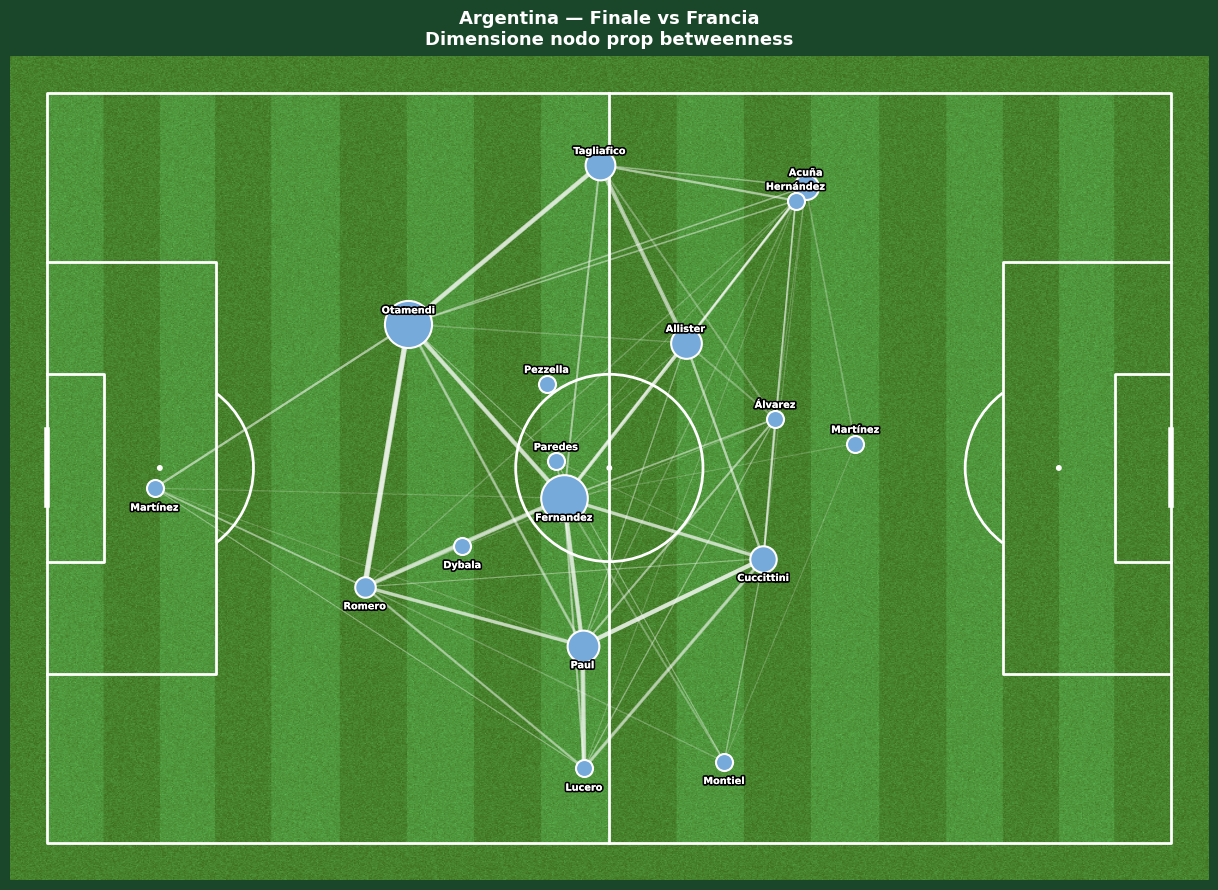

In [10]:
def plot_network_on_pitch(G, team_name, ax=None, title=None):
    """
    Disegna la rete di passaggio sul campo da calcio.
    Nodi: posizione media, dimensione prop betweenness, colore = squadra.
    Archi: soglia e spessore ADATTIVI al peso massimo della rete, così la
    figura resta leggibile sia su una singola partita sia sull'aggregato di
    torneo (dove i pesi sono molto più alti).

    Leggibilita label (dv05 best practices: labelling):
    - Testo sempre orizzontale (tilted text is not legible)
    - path_effects con contorno nero -> leggibile su qualsiasi sfondo
    - Offset adattivo: label sotto i nodi nella meta alta del campo (y>40),
      sopra nella meta bassa -> minimizza uscite dai bordi del campo.
    """
    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="grass",
        line_color="white",
        stripe=True
    )

    if ax is None:
        fig, ax = pitch.draw(figsize=(12, 8))
    else:
        pitch.draw(ax=ax)

    # Betweenness per dimensione dei nodi
    bc = nx.betweenness_centrality(G, weight="distance", normalized=True)
    max_bc = max(bc.values()) if bc else 1

    # Scala adattiva degli archi rispetto al peso massimo della rete
    max_w = max((d["weight"] for *_, d in G.edges(data=True)), default=1)
    edge_thresh = max(2, max_w * 0.08)     # soglia ~8% del peso massimo

    # Disegna archi (spessore/alpha normalizzati e con cap)
    for u, v, d in G.edges(data=True):
        if d["weight"] >= edge_thresh:
            x1 = G.nodes[u].get("avg_x", 60)
            y1 = G.nodes[u].get("avg_y", 40)
            x2 = G.nodes[v].get("avg_x", 60)
            y2 = G.nodes[v].get("avg_y", 40)
            frac  = d["weight"] / max_w
            alpha = min(0.15 + 0.55 * frac, 0.7)
            lw    = 0.4 + 3.6 * frac           # cap implicito ~4.0
            ax.plot([x1, x2], [y1, y2], color="white",
                    alpha=alpha, linewidth=lw, zorder=3)

    # path_effects condivisi: contorno nero spesso garantisce leggibilita
    # su sfondo verde, archi bianchi e nodi colorati (dv05 labelling).
    label_effects = [
        pe.withStroke(linewidth=2.5, foreground="black"),
        pe.Normal()
    ]

    # Disegna nodi e label
    for node in G.nodes():
        x     = G.nodes[node].get("avg_x", 60)
        y     = G.nodes[node].get("avg_y", 40)
        size  = 150 + (bc.get(node, 0) / max_bc) * 1000
        color = TEAM_COLORS.get(team_name, "#888888")

        ax.scatter(x, y, s=size, c=color,
                   edgecolors="white", linewidth=1.5, zorder=5)

        short = node.split()[-1]

        # Offset adattivo: nodi nella meta alta del campo (y StatsBomb > 40)
        # ricevono il label sotto, gli altri sopra. Evita label fuori bordo
        # senza librerie aggiuntive, in linea con dv05 "no unjustified 2D".
        y_offset = 10 if y <= 40 else -14

        ax.annotate(
            short, (x, y),
            fontsize=7,
            ha="center", va="center",
            xytext=(0, y_offset),
            textcoords="offset points",
            color="white",
            fontweight="bold",
            zorder=6,
            path_effects=label_effects
        )

    ax.set_title(title or team_name, fontsize=13,
                 fontweight="bold", color="white", pad=8)
    return ax


# Testa sulla finale dell'Argentina
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor("#1a472a")
plot_network_on_pitch(G_arg_finale, "Argentina", ax=ax,
                      title="Argentina — Finale vs Francia\n"
                            "Dimensione nodo prop betweenness")
plt.tight_layout()
plt.savefig("hero_argentina_finale.png", dpi=150, bbox_inches="tight")
plt.show()


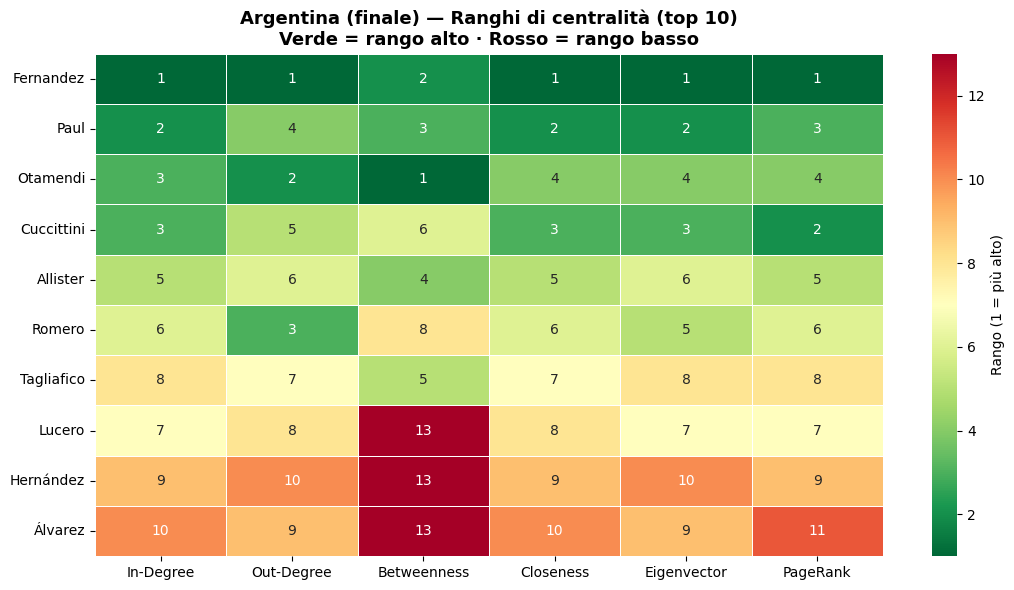

In [11]:
def plot_heatmap(centralities_df, team_name, vmax=None):
    """
    Heatmap dei ranghi di centralità per i top-10 giocatori.
    Celle verdi = rango alto, celle rosse = rango basso.
    Giocatori con colori uniformi sono dominanti in tutto.
    Giocatori con colori variabili hanno profili specializzati.

    vmax : int, optional
        Valore massimo della scala colore. Se None viene calcolato localmente.
        Per confronti tra squadre passare un vmax comune (es. numero totale
        di giocatori della squadra più grande) così la palette è uniforme.
    """
    measures = ["in_degree", "out_degree", "betweenness", "closeness",
                "eigenvector", "pagerank"]
    labels   = ["In-Degree", "Out-Degree", "Betweenness",
                "Closeness", "Eigenvector", "PageRank"]

    ranks = centralities_df[measures].rank(ascending=False).astype(int)
    ranks["_total"] = ranks.sum(axis=1)
    top10 = ranks.nsmallest(10, "_total").drop(columns="_total")

    short_names = [n.split()[-1] for n in top10.index]

    # Scala colore: vmin fisso a 1 (rango migliore),
    # vmax passato dall'esterno per uniformità cross-squadra
    _vmax = vmax if vmax is not None else int(top10.values.max())

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.heatmap(
        top10.values,
        annot=True, fmt="d",
        xticklabels=labels,
        yticklabels=short_names,
        cmap="RdYlGn_r",
        vmin=1,
        vmax=_vmax,
        linewidths=0.5,
        cbar_kws={"label": "Rango (1 = più alto)"},
        ax=ax
    )
    ax.set_title(
        f"{team_name} — Ranghi di centralità (top 10)\n"
        f"Verde = rango alto · Rosso = rango basso",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"heatmap_{team_name.lower().replace(' ','_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()


plot_heatmap(cent_arg, "Argentina (finale)")


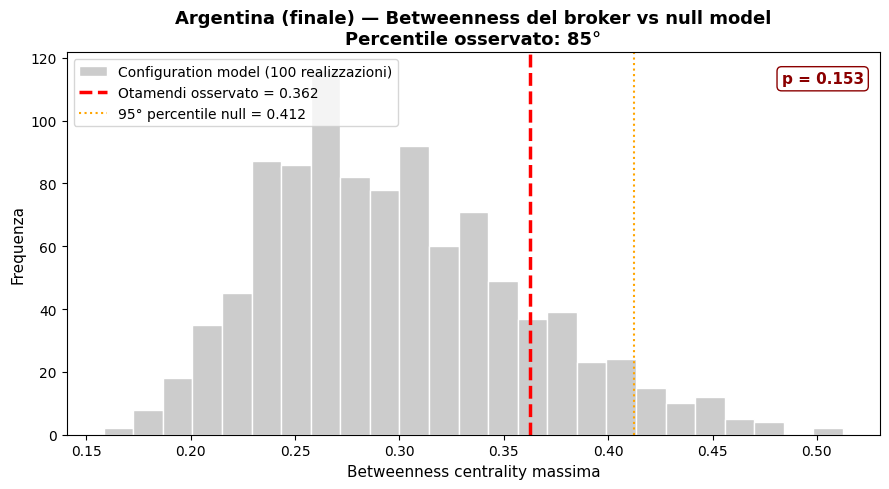

In [12]:
def plot_null_model(observed_bc, null_dist, team_name, broker_name):
    """
    Istogramma della distribuzione del null model con la betweenness
    osservata sovrapposta come linea verticale rossa.
    """
    p95  = np.percentile(null_dist, 95)
    perc = np.mean([x < observed_bc for x in null_dist]) * 100
    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(null_dist, bins=25, color="#cccccc",
            edgecolor="white", label="Configuration model (100 realizzazioni)")
    ax.axvline(observed_bc, color="red", lw=2.5, linestyle="--",
               label=f"{broker_name.split()[-1]} osservato = {observed_bc:.3f}")
    ax.axvline(p95, color="orange", lw=1.5, linestyle=":",
               label=f"95° percentile null = {p95:.3f}")
    
    ax.set_xlabel("Betweenness centrality massima", fontsize=11)
    ax.set_ylabel("Frequenza", fontsize=11)
    ax.set_title(
        f"{team_name} — Betweenness del broker vs null model\n"
        f"Percentile osservato: {perc:.0f}°",
        fontsize=13, fontweight="bold"
    )
    ax.legend(fontsize=10)
    p_val = np.mean(null_dist >= observed_bc)
    p_label = "p < 0.01" if p_val < 0.01 else f"p = {p_val:.3f}"
    ax.text(0.98, 0.95, p_label, transform=ax.transAxes,
            ha="right", va="top", fontsize=11, fontweight="bold",
            color="#8B0000",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#8B0000"))
    plt.tight_layout()
    plt.savefig(
        f"null_{team_name.lower().replace(' ','_')}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()


plot_null_model(
    observed_bc   = cent_arg.loc[profiles_arg["broker"], "betweenness"],
    null_dist     = null_dist_arg,
    team_name     = "Argentina (finale)",
    broker_name   = profiles_arg["broker"]
)

## 10. Analisi aggregata — le quattro semifinaliste sul torneo intero

Fino a qui abbiamo lavorato sulla sola finale dell'Argentina come caso pilota.
Adesso estendiamo l'analisi a **tutte le partite del torneo** per ciascuna
delle quattro semifinaliste.

La rete aggregata somma i passaggi di tutte le partite giocate.
Applichiamo una soglia di **30 minuti stimati** nel torneo (ricavati dagli
eventi Starting XI, +90 per ogni titolare, corretti dalle sostituzioni) per
escludere i subentrati brevi. È lo stesso criterio di inclusione usato in RQ3,
così le reti dei due notebook sono identiche.

Il risultato finale è una tabella comparativa dei profili strutturali
delle quattro squadre.

In [13]:
def build_tournament_network(team_name, matches_df, min_minutes=30):
    """
    Costruisce la rete aggregata di passaggio per una squadra su tutto il torneo.
    Applica una soglia sui minuti stimati (Starting XI + sostituzioni) per
    escludere i subentrati brevi -> criterio identico a RQ3.
    """
    print(f"\nCaricamento {team_name}...")

    team_matches = matches_df[
        (matches_df["home_team"] == team_name) |
        (matches_df["away_team"] == team_name)
    ]

    all_passes = []
    player_total_minutes = {}

    for _, match in team_matches.iterrows():
        mid = match["match_id"]
        events = sb.events(match_id=mid)

        passes = events[
            (events["type"] == "Pass") &
            (events["team"] == team_name) &
            (events["pass_outcome"].isna())
        ].copy()

        # Stima minuti: Starting XI (+90 a chi parte titolare) corretto dalle sostituzioni
        lineups = events[(events["type"] == "Starting XI") & (events["team"] == team_name)]
        for _, row in lineups.iterrows():
            tac = row.get("tactics")
            if isinstance(tac, dict):
                for p in tac.get("lineup", []):
                    nm = p["player"]["name"]
                    player_total_minutes[nm] = player_total_minutes.get(nm, 0) + 90

        subs = events[(events["type"] == "Substitution") & (events["team"] == team_name)]
        for _, row in subs.iterrows():
            passer = row.get("player")
            si = row.get("substitution")
            if not isinstance(si, dict):
                continue
            off = passer["name"] if isinstance(passer, dict) else passer
            on = si["replacement"]["name"]
            minute = row.get("minute", 90)
            if off in player_total_minutes:
                player_total_minutes[off] -= (90 - minute)
            else:
                player_total_minutes[off] = minute
            player_total_minutes[on] = player_total_minutes.get(on, 0) + (90 - minute)

        passes["x_start"] = passes["location"].apply(
            lambda l: l[0] if isinstance(l, list) else np.nan
        )
        passes["y_start"] = passes["location"].apply(
            lambda l: l[1] if isinstance(l, list) else np.nan
        )
        passes_clean = passes[
            ["player", "pass_recipient", "x_start", "y_start"]
        ].dropna(subset=["player", "pass_recipient"])
        passes_clean.columns = ["passer", "recipient", "x_start", "y_start"]
        all_passes.append(passes_clean)

    passes_df = pd.concat(all_passes, ignore_index=True)

    # Filtra i giocatori con meno di min_minutes minuti stimati:
    eligible = {
        p for p, mn in player_total_minutes.items()
        if mn >= min_minutes
    }
    passes_df = passes_df[
        passes_df["passer"].isin(eligible) &
        passes_df["recipient"].isin(eligible)
    ]

    # Posizione media
    avg_pos = passes_df.groupby("passer")[["x_start", "y_start"]].mean()

    # Costruisci grafo
    edge_w = (
        passes_df.groupby(["passer", "recipient"])
        .size().reset_index(name="weight")
    )

    G = nx.DiGraph()
    for _, row in edge_w.iterrows():
        G.add_edge(
            row["passer"], row["recipient"],
            weight=row["weight"],
            distance=1.0 / row["weight"]
        )

    for node in G.nodes():
        if node in avg_pos.index:
            G.nodes[node]["avg_x"] = avg_pos.loc[node, "x_start"]
            G.nodes[node]["avg_y"] = avg_pos.loc[node, "y_start"]
        else:
            # nodo presente solo come ricevitore: default al centro campo
            G.nodes[node]["avg_x"] = 60.0
            G.nodes[node]["avg_y"] = 40.0

    print(f"  → {G.number_of_nodes()} nodi, {G.number_of_edges()} archi, "
          f"{sum(d['weight'] for _,_,d in G.edges(data=True))} passaggi")

    return G


# Costruisci le reti per tutte e quattro le semifinaliste
team_graphs = {}
for team in SEMIFINALISTS:
    team_graphs[team] = build_tournament_network(team, matches, min_minutes=MIN_MINUTES)



Caricamento Argentina...
  → 18 nodi, 260 archi, 3756 passaggi

Caricamento France...
  → 22 nodi, 290 archi, 3140 passaggi

Caricamento Croatia...
  → 19 nodi, 273 archi, 3785 passaggi

Caricamento Morocco...
  → 17 nodi, 213 archi, 2124 passaggi


vmax globale heatmap: 22 giocatori


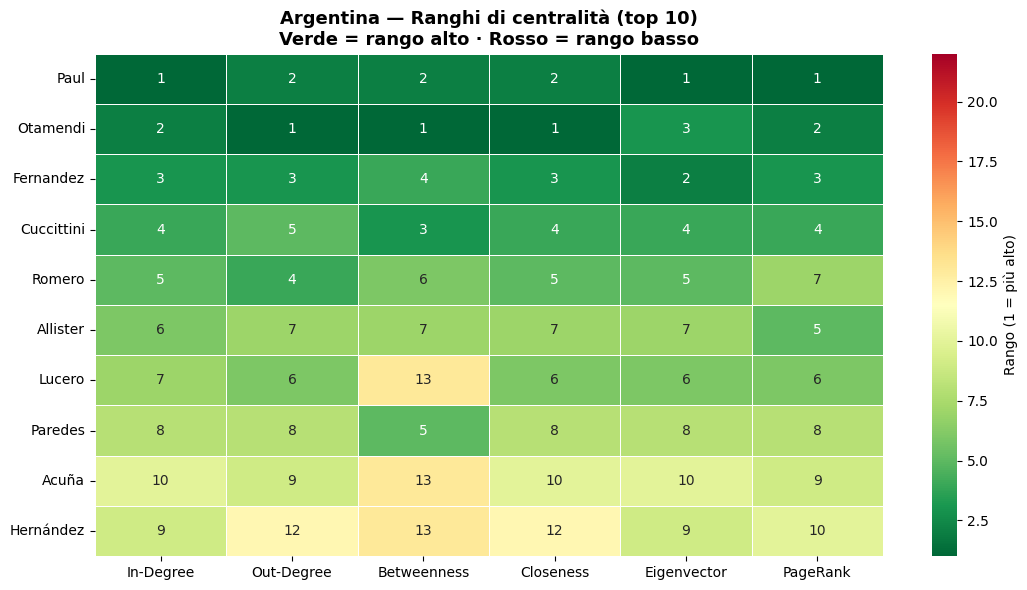

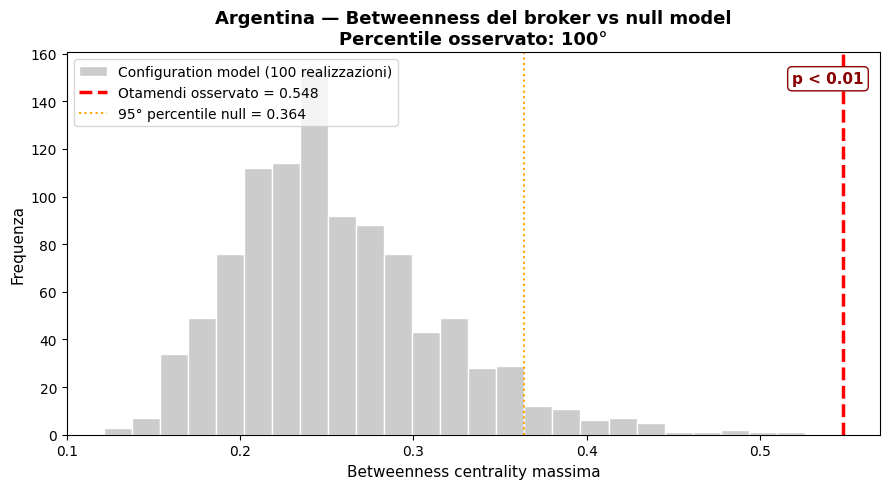

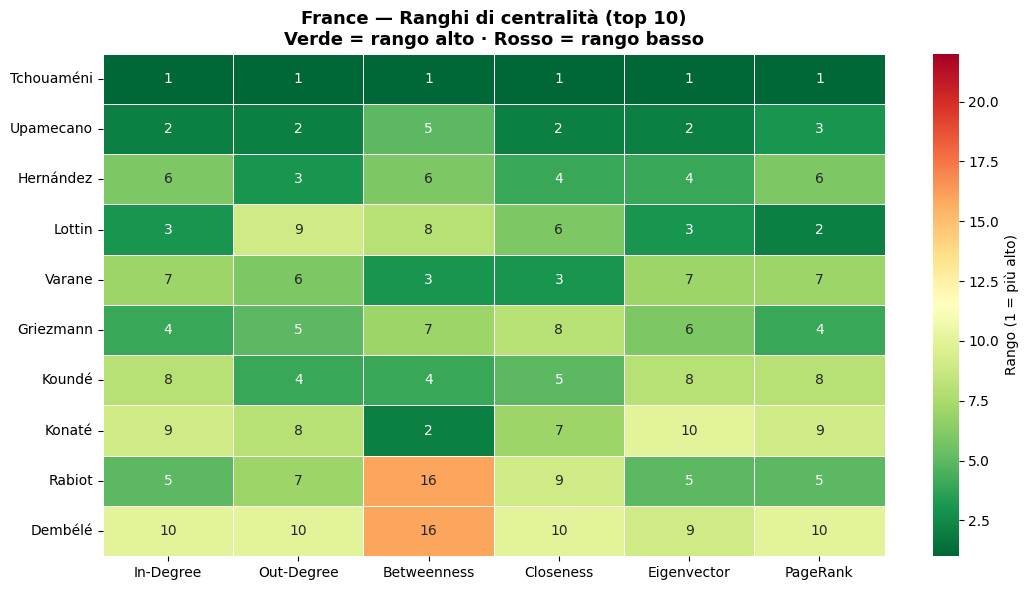

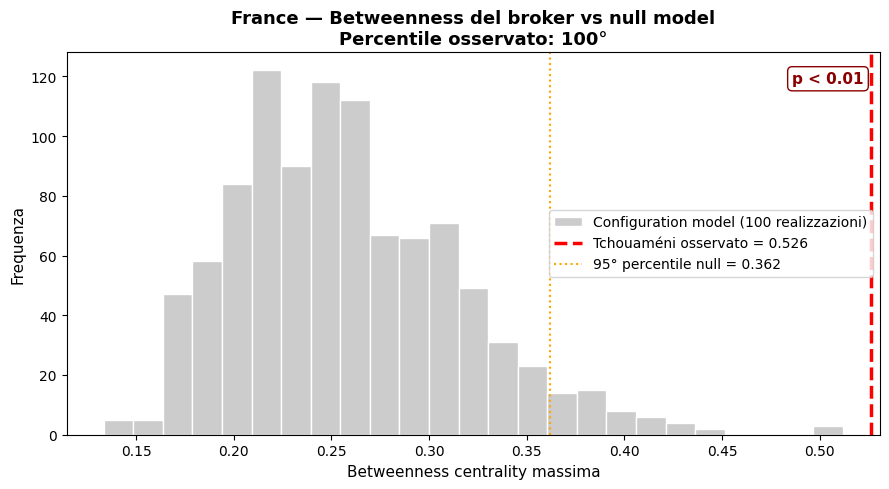

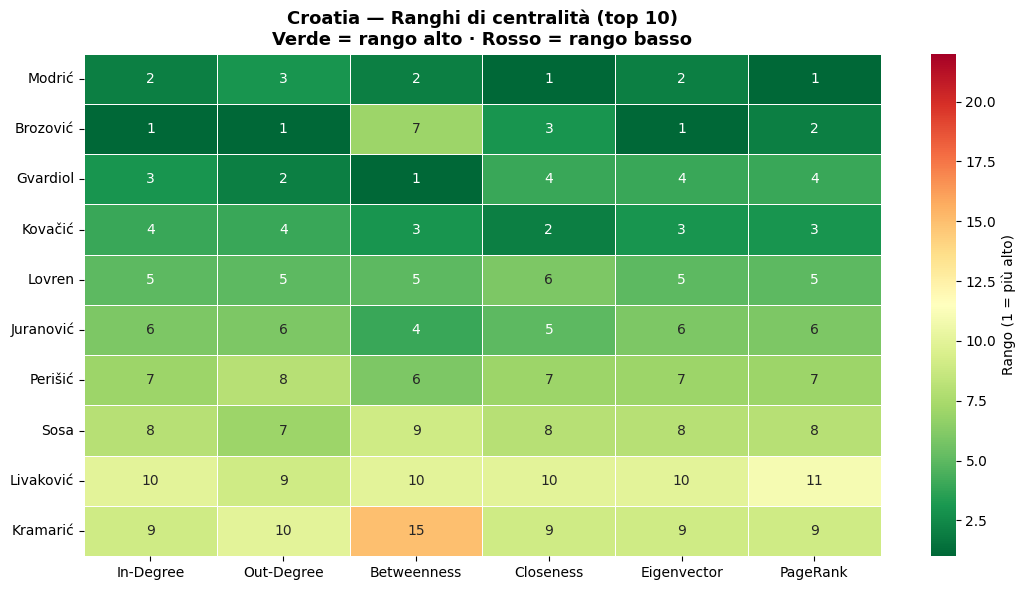

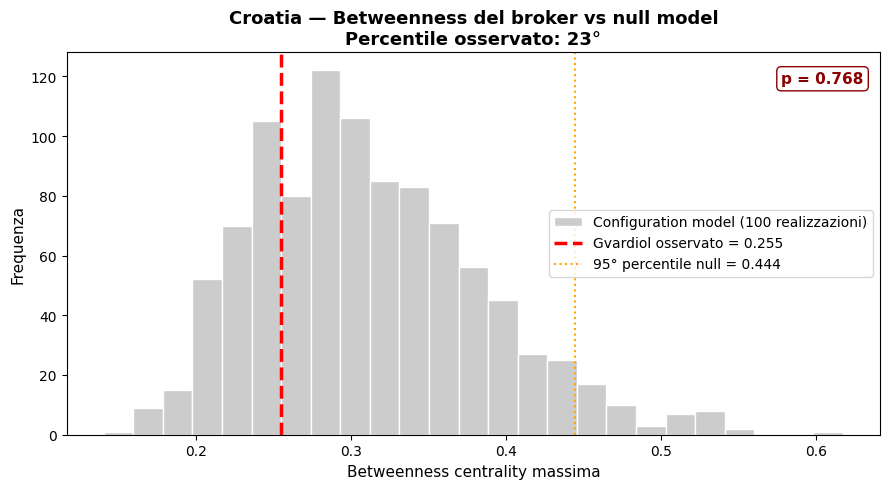

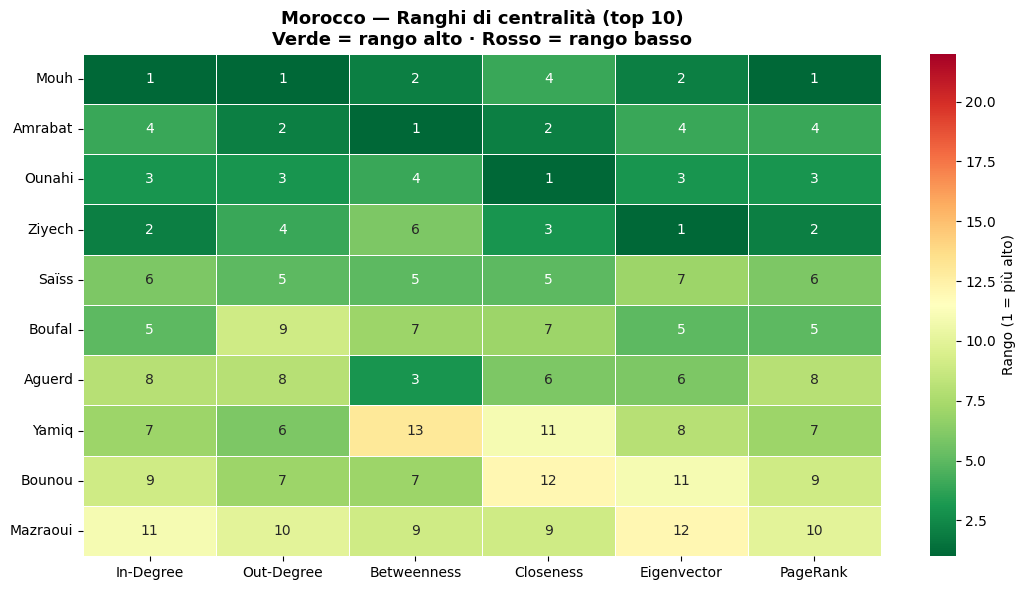

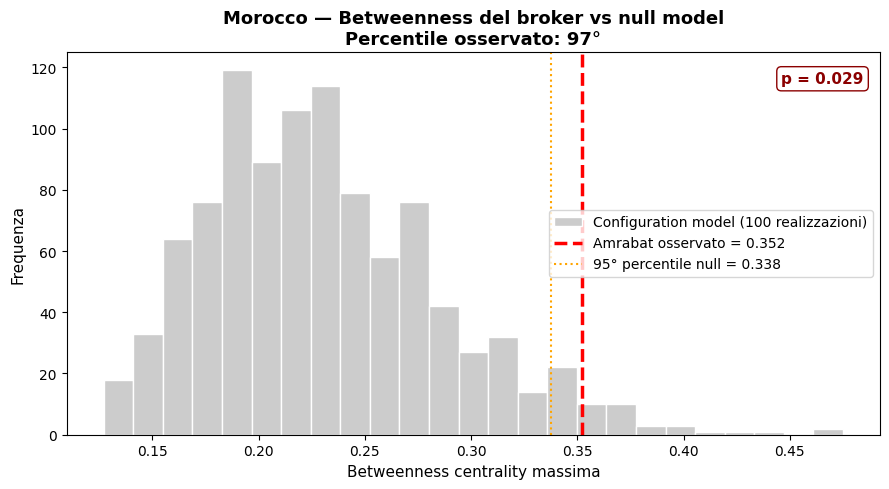


RIEPILOGO RQ1 — Profili strutturali delle quattro semifinaliste
          nodi archi      broker broker_bc terminal  metronome null_p95 significant
Argentina   18   260    Otamendi    0.5478     Paul  Fernandez    0.364           ✓
France      22   290  Tchouaméni    0.5262   Lottin  Upamecano    0.362           ✓
Croatia     19   273    Gvardiol    0.2549   Modrić   Brozović   0.4444           ✗
Morocco     17   213     Amrabat    0.3521   Ziyech       Mouh   0.3375           ✓


In [14]:
# Calcola centralità, profili e null model per tutte le squadre
# e produce la tabella comparativa finale

results = {}

# Calcola il vmax globale = numero di giocatori della squadra con il roster
# più ampio tra le quattro semifinaliste (usato per uniformare la scala colore
# delle heatmap e rendere i grafici direttamente comparabili tra squadre).
_all_player_counts = [
    compute_centralities(team_graphs[t]).shape[0]
    for t in SEMIFINALISTS
]
GLOBAL_VMAX = max(_all_player_counts)
print(f"vmax globale heatmap: {GLOBAL_VMAX} giocatori")

for team in SEMIFINALISTS:
    G    = team_graphs[team]
    cent = compute_centralities(G)
    prof = identify_profiles(cent)
    
    broker_bc = cent.loc[prof["broker"], "betweenness"]
    null_dist = null_model_test(G, n_realisations=1000)
    p95       = np.percentile(null_dist, 95)
    
    results[team] = {
        "nodi":       G.number_of_nodes(),
        "archi":      G.number_of_edges(),
        "broker":     prof["broker"].split()[-1],
        "broker_bc":  round(broker_bc, 4),
        "terminal":   prof["terminal"].split()[-1],
        "metronome":  prof["metronome"].split()[-1],
        "null_p95":   round(p95, 4),
        "significant": "✓" if broker_bc > p95 else "✗",
    }
    
    # Produce le figure per questa squadra
    plot_heatmap(cent, team, vmax=GLOBAL_VMAX)
    plot_null_model(broker_bc, null_dist, team, prof["broker"])

# Tabella riassuntiva
summary = pd.DataFrame(results).T
print("\n" + "="*70)
print("RIEPILOGO RQ1 — Profili strutturali delle quattro semifinaliste")
print("="*70)
print(summary.to_string())

In [ ]:
# Delta-rank slope chart: Argentina torneo vs finale
# (self-contained: ricalcola le centralita di torneo da team_graphs, cosi non
#  dipende dall'ordine di esecuzione di altre celle)
measures = ["in_degree","out_degree","betweenness","closeness","eigenvector","pagerank"]

cent_arg_torneo = compute_centralities(team_graphs["Argentina"])
ranks_torneo = cent_arg_torneo[measures].rank(ascending=False).astype(int)
ranks_finale = cent_arg[measures].rank(ascending=False).astype(int)

# Giocatori presenti in entrambe le reti
comuni = ranks_torneo.index.intersection(ranks_finale.index)

# Rango medio composito
rank_medio_torneo = ranks_torneo.loc[comuni].mean(axis=1)
rank_medio_finale = ranks_finale.loc[comuni].mean(axis=1)

def adjust_labels(positions, min_gap=0.75):
    n = len(positions)
    order = sorted(range(n), key=lambda i: positions[i])
    adj = [positions[order[k]] for k in range(n)]
    for _ in range(300):
        moved = False
        for k in range(n - 1):
            if adj[k + 1] - adj[k] < min_gap:
                mid = (adj[k] + adj[k + 1]) / 2
                adj[k]     = mid - min_gap / 2
                adj[k + 1] = mid + min_gap / 2
                moved = True
        if not moved:
            break
    result = [0.0] * n
    for k, orig_i in enumerate(order):
        result[orig_i] = adj[k]
    return result

players_list = list(comuni)
r_t_list = [rank_medio_torneo[p] for p in players_list]
r_f_list = [rank_medio_finale[p] for p in players_list]

adj_t = adjust_labels(r_t_list)
adj_f = adjust_labels(r_f_list)

fig, ax = plt.subplots(figsize=(8, 9))

for i, player in enumerate(players_list):
    r_t = r_t_list[i]
    r_f = r_f_list[i]
    delta = r_t - r_f
    color = "#2ecc71" if delta > 1.5 else "#e74c3c" if delta < -1.5 else "#aaaaaa"
    ax.plot([0, 1], [r_t, r_f], color=color, linewidth=1.5, alpha=0.8)

for i, player in enumerate(players_list):
    ax.text(-0.05, adj_t[i], player.split()[-1], ha="right", fontsize=8, va="center")
    ax.text(1.05, adj_f[i], player.split()[-1], ha="left", fontsize=8, va="center")

ax.set_xlim(-0.3, 1.3)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Torneo\n(7 partite)", "Finale\nvs Francia"])
ax.invert_yaxis()
ax.set_ylabel("Rango composito (1 = più centrale)")
ax.set_title(
    "Argentina — Variazione ranghi: Torneo -> Finale\n"
    "Verde = scala, Rosso = scende, Grigio = stabile"
)
plt.tight_layout()
plt.savefig("delta_rank_argentina.png", dpi=150, bbox_inches="tight")
plt.show()


SyntaxError: unterminated string literal (detected at line 58) (2349033384.py, line 58)

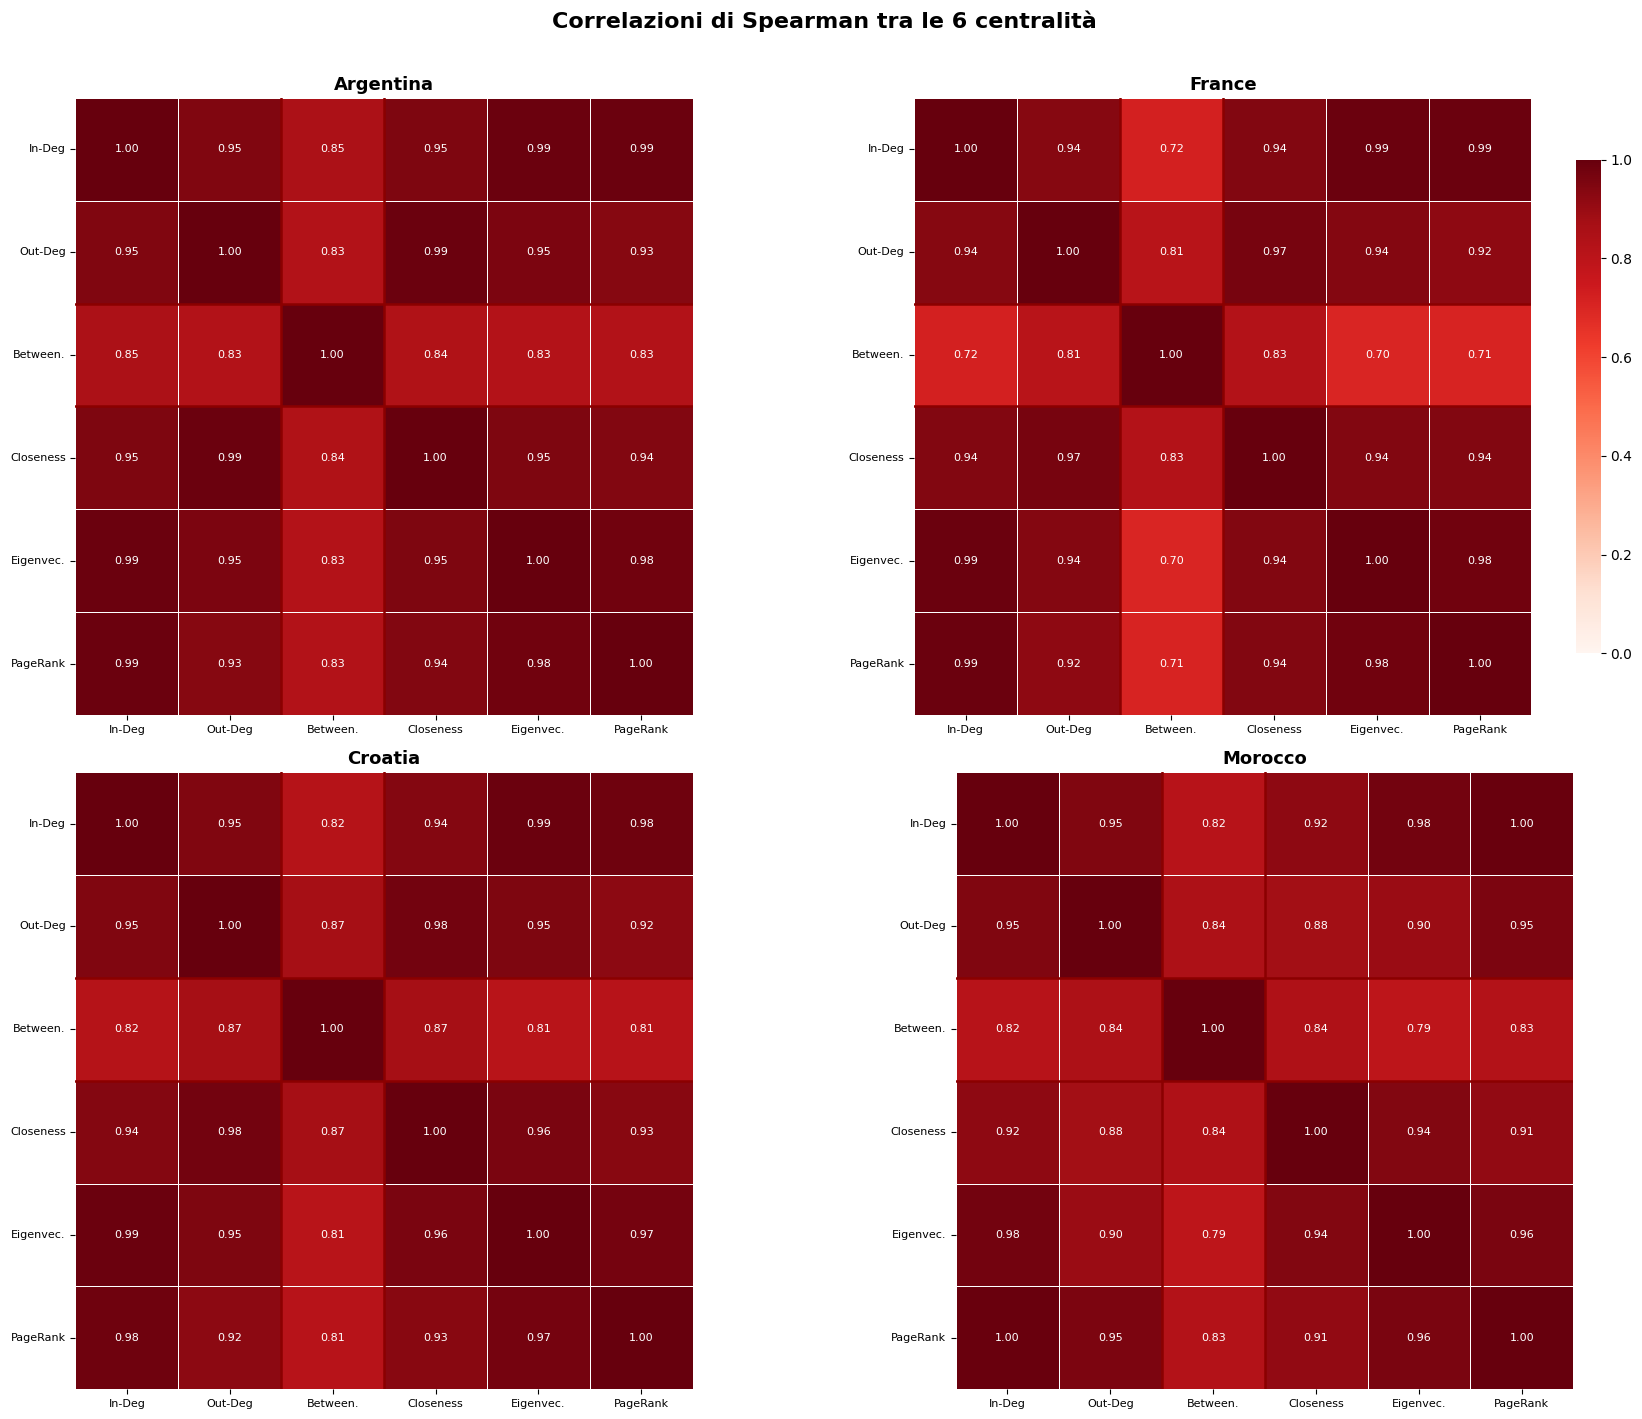

Salvato: rq1_spearman_all.png


In [ ]:
# ── Plot 2x2 correlazioni di Spearman — tutte e 4 le semifinaliste ──────────
#
# Genera rq1_spearman_all.png: griglia 2x2 con la matrice 6x6 di Spearman
# per Argentina, France, Croatia, Morocco.
#
# Dipende da: team_centralities (dict popolato nel loop di cell 25)

if "team_centralities" not in dir() or not team_centralities:
    team_centralities = {t: compute_centralities(team_graphs[t]) for t in SEMIFINALISTS}

labels_short = ["In-Deg", "Out-Deg", "Between.", "Closeness", "Eigenvec.", "PageRank"]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Correlazioni di Spearman tra le 6 centralità",
             fontsize=16, fontweight="bold", y=1.01)

for idx, team in enumerate(SEMIFINALISTS):
    row, col = divmod(idx, 2)
    ax = axes[row][col]

    corr_df, _ = compute_spearman(team_centralities[team])
    corr_df.index   = labels_short
    corr_df.columns = labels_short

    sns.heatmap(
        corr_df,
        annot=True, fmt=".2f",
        cmap="Reds",
        vmin=0, vmax=1,
        linewidths=0.4,
        linecolor="white",
        square=True,
        cbar=(idx == 1),          # colorbar solo sul primo subplot in alto a dx
        cbar_kws={"shrink": 0.8},
        ax=ax,
        annot_kws={"size": 8}
    )

    ax.set_title(team, fontsize=13, fontweight="bold", pad=6)

    # Evidenzia la riga/colonna Betweenness con bordo rosso scuro (dv05:
    # rendere visibili le divergenze strutturali chiave)
    between_idx = labels_short.index("Between.")
    for spine_pos in [between_idx, between_idx + 1]:
        ax.axhline(spine_pos, color="#8B0000", linewidth=1.8, zorder=5)
        ax.axvline(spine_pos, color="#8B0000", linewidth=1.8, zorder=5)

    # Ruota le etichette x orizzontalmente (dv05: tilted text isn't legible)
    ax.set_xticklabels(labels_short, rotation=0, fontsize=8)
    ax.set_yticklabels(labels_short, rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig("rq1_spearman_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvato: rq1_spearman_all.png")


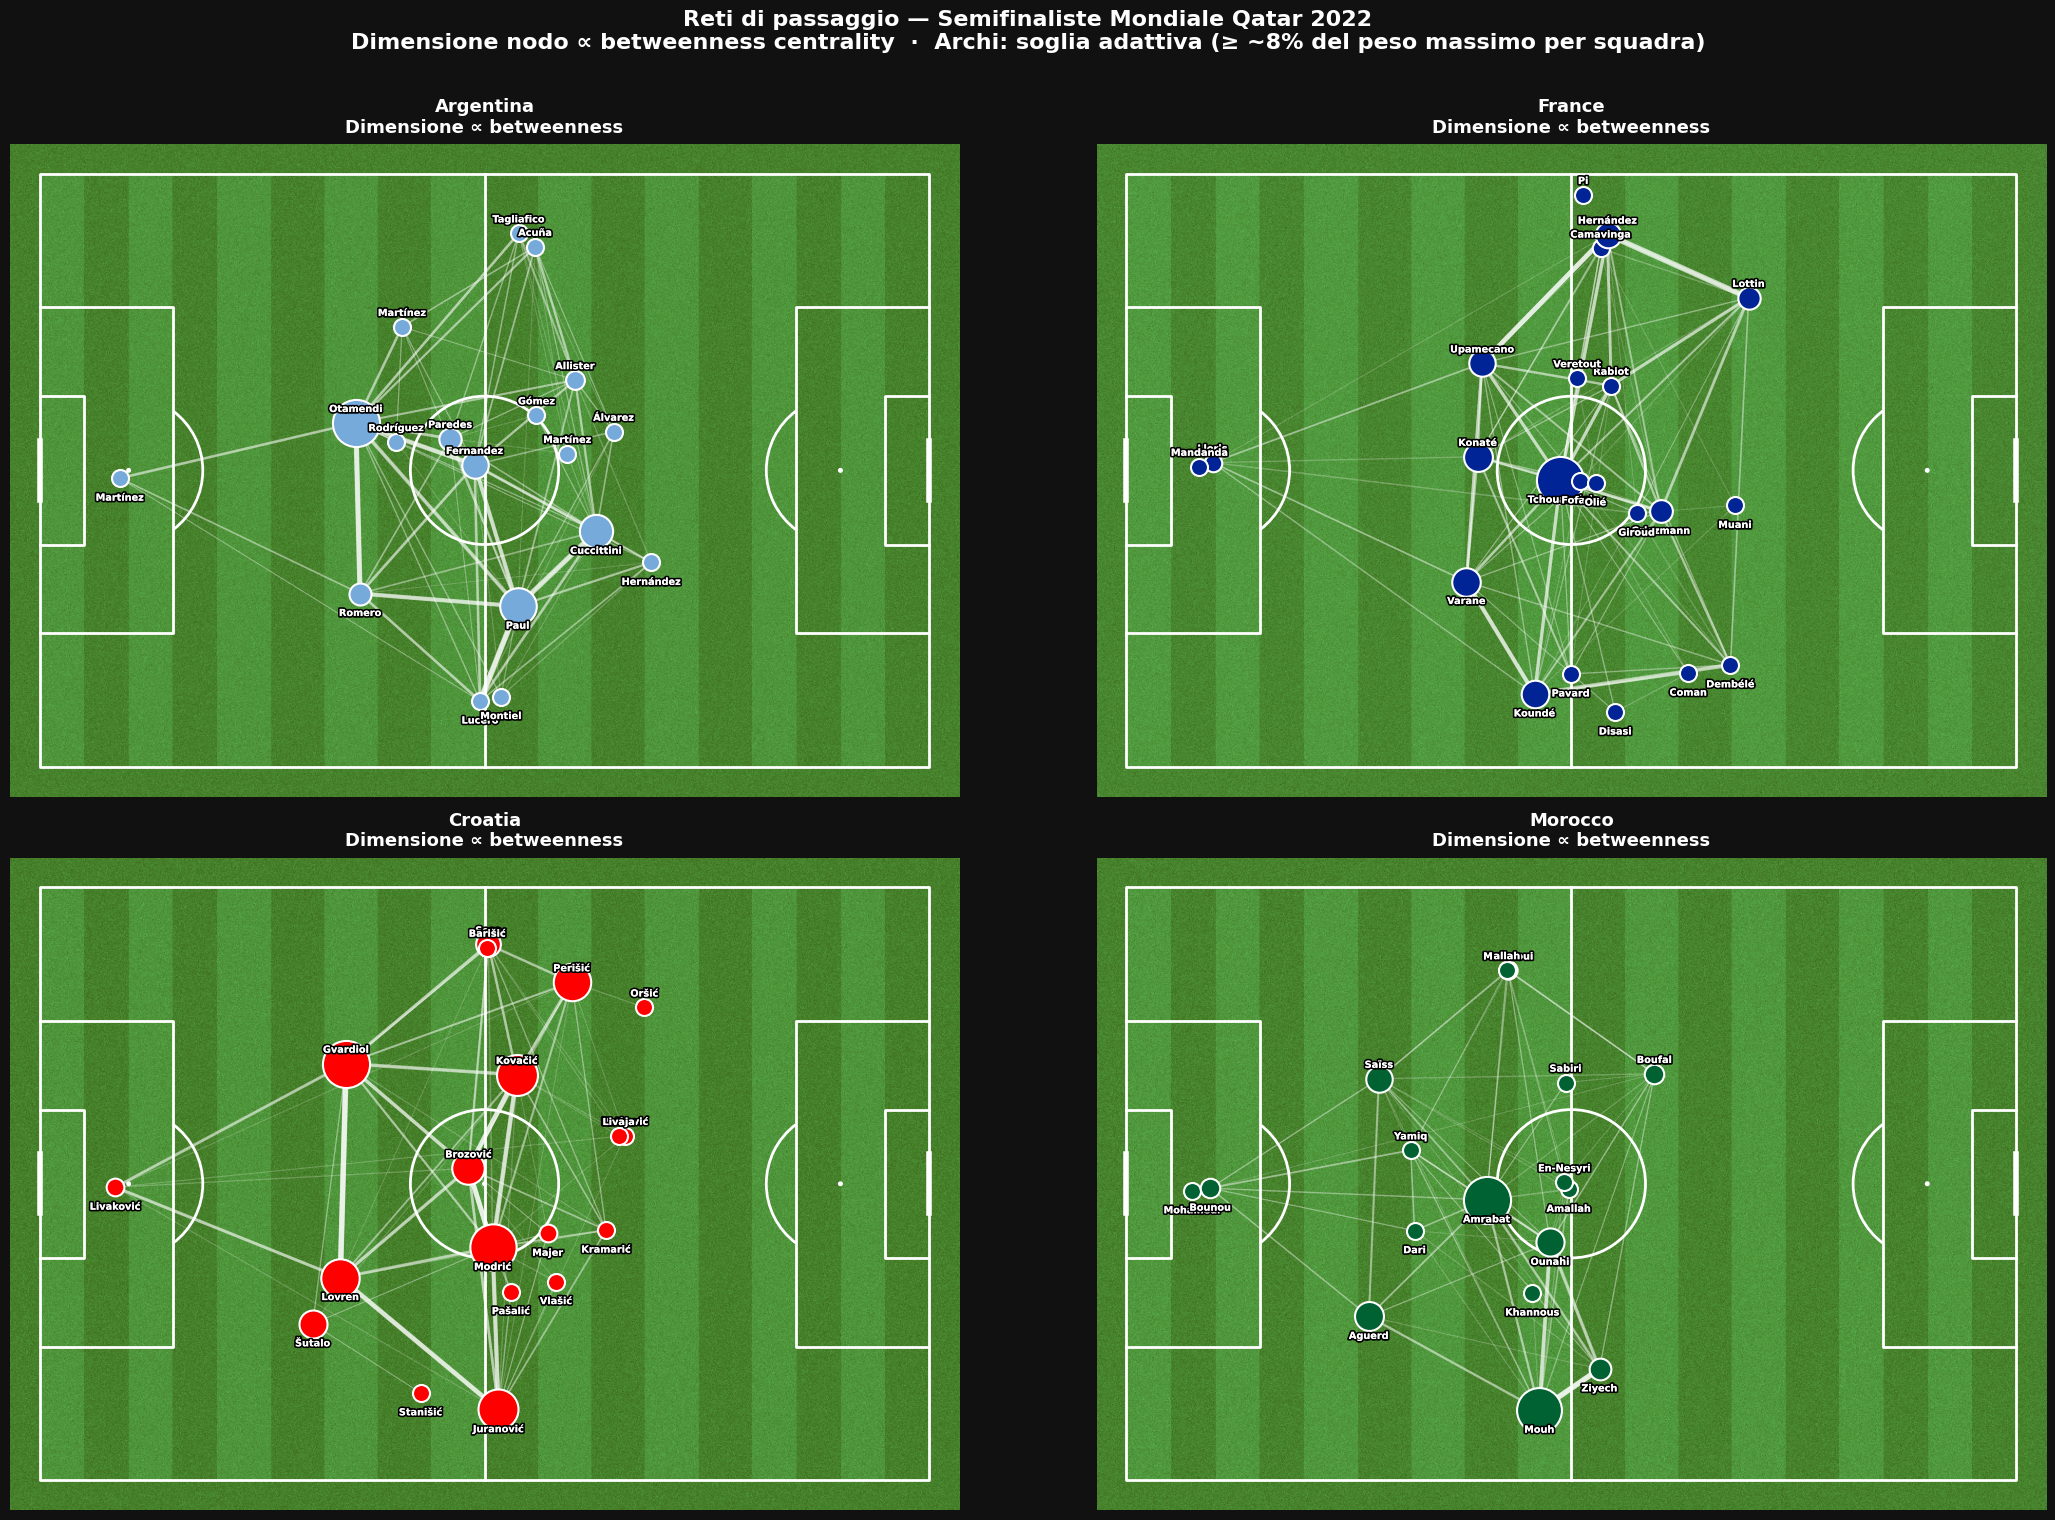

✓ Hero figure salvata: hero_figure_4teams.png


In [ ]:
# Hero figure 2x2 con tutte le squadre
fig, axes = plt.subplots(2, 2, figsize=(22, 15))
fig.patch.set_facecolor("#111111")

for idx, team in enumerate(SEMIFINALISTS):
    row, col = divmod(idx, 2)
    plot_network_on_pitch(
        team_graphs[team], team,
        ax=axes[row][col],
        title=f"{team}\nDimensione ∝ betweenness"
    )

fig.suptitle(
    "Reti di passaggio — Semifinaliste Mondiale Qatar 2022\n"
    "Dimensione nodo ∝ betweenness centrality  ·  "
    "Archi: soglia adattiva (≥ ~8% del peso massimo per squadra)",
    fontsize=16, fontweight="bold", color="white", y=1.01
)
plt.tight_layout()
plt.savefig("hero_figure_4teams.png", dpi=200, bbox_inches="tight",
            facecolor="#111111")
plt.show()
print("✓ Hero figure salvata: hero_figure_4teams.png")

### 3.1 Analisi delle Centralità (RQ1)

Per ciascuna delle quattro semifinaliste abbiamo costruito una singola rete 
diretta e pesata aggregando tutte le partite giocate durante il torneo. I nodi 
rappresentano i giocatori che hanno accumulato almeno 30 minuti stimati 
nel corso del torneo (calcolati da Starting XI + sostituzioni); gli archi 
diretti collegano il passante al ricevitore, con peso pari al numero totale 
di passaggi completati tra quella coppia. 
I passaggi con campo `pass_outcome` non nullo nei dati di evento StatsBomb 
sono stati esclusi, conservando solo i passaggi completati con successo.

Abbiamo calcolato sei misure di centralità su ogni rete:

- **In-degree pesato**: proporzione del peso totale di passaggi ricevuti da 
  un giocatore, misura con quale frequenza un giocatore viene cercato come 
  destinatario.
- **Out-degree pesato**: proporzione del peso totale di passaggi distribuiti 
  da un giocatore, misura il volume di passaggi effettuati.
- **Betweenness centrality pesata**: frazione dei cammini più corti tra tutte 
  le coppie di giocatori che transitano attraverso un dato nodo, utilizzando 
  la distanza d = 1/w, dove w è il peso dell'arco. Questa convenzione garantisce 
  che le corsie di passaggio più utilizzate corrispondano a distanze brevi. 
  Tutti i valori di betweenness sono normalizzati nell'intervallo [0,1].
- **Closeness centrality pesata**: inverso della distanza media del cammino 
  più corto da un nodo a tutti gli altri nodi raggiungibili, usando anch'essa 
  d = 1/w.
- **Eigenvector centrality**: misura ricorsiva in cui il punteggio di un 
  giocatore è proporzionale alla somma dei punteggi dei suoi vicini, usando 
  direttamente i pesi degli archi.
- **PageRank**: distribuzione stazionaria di una passeggiata casuale sulla 
  rete diretta e pesata con probabilità di teletrasporto α = 0.85, che 
  approssima la probabilità a lungo termine che il pallone si trovi presso 
  un dato giocatore.

Per valutare se il pivot strutturale identificato sia statisticamente 
significativo — e non un artefatto della sola struttura dei gradi — abbiamo 
confrontato la betweenness pesata massima osservata con un null model coerente. 
Abbiamo generato 100 realizzazioni di un configuration model diretto che 
preserva la sequenza di in-degree e out-degree non pesata di ogni nodo (il 
numero di partner distinti), rimosso i self-loop e gli archi paralleli, e 
ridistribuito casualmente i pesi osservati sugli archi del grafo nullo. Su 
ciascuna realizzazione abbiamo calcolato la betweenness pesata (distance = 
1/peso), identica a quella usata sull'osservato, e registrato il valore 
massimo. Il valore osservato è stato poi collocato nella distribuzione 
empirica risultante.

Le correlazioni di Spearman a coppie tra tutte e sei le misure sono state 
calcolate per quantificare il grado di concordanza tra le definizioni di 
centralità e per identificare i giocatori i cui ranghi divergono tra le misure.

### 4.1 Pivot Strutturali e Profili di Centralità

La Tabella 1 riassume il pivot strutturale (broker), il terminal e il metronome
identificati per ciascuna semifinalista, con la betweenness pesata del broker, il
95° percentile del null model coerente (sezione 3.1) e il loro rapporto.

| Squadra   | Broker      | Betweenness | Null 95° pct | Rapporto      | Terminal | Metronome      |
|-----------|-------------|-------------|--------------|---------------|----------|----------------|
| Argentina | Otamendi    | 0.548       | 0.364        | 1.51× ✓       | De Paul  | E. Fernández   |
| Francia   | Tchouaméni  | 0.526       | 0.362        | 1.45× ✓       | Lottin   | Upamecano      |
| Marocco   | Amrabat     | 0.352       | 0.338        | 1.04× ✓ (marg.) | Ziyech   | A. Hakimi      |
| Croazia   | Gvardiol    | 0.255       | 0.444        | 0.57× ✗       | Modrić   | Brozović       |

*Tabella 1. Profili strutturali delle quattro semifinaliste. ✓/✗ indica se la
betweenness pesata osservata supera il 95° percentile del null model coerente
(degree-sequence preservata + ridistribuzione dei pesi + betweenness pesata).*

A differenza di un null model non pesato, il test coerente è più conservativo.
Con 1000 realizzazioni a seme fisso (seed0=0) la brokerage supera il 95°
percentile per **Argentina** (1.51×, netta), **Francia** (1.45×, netta) e
**Marocco** (1.04×, ✓ ma **borderline** — il caso più vicino alla soglia); la
**Croazia** non raggiunge la significatività (0.57×). Il Marocco è il caso di
confine dell'analisi: la betweenness di Amrabat supera la soglia di pochissimo e
il risultato è sensibile alle impostazioni del null model. Lo stesso test
applicato alla sola *finale* dell'Argentina (caso pilota) colloca Otamendi al 78°
percentile (non significativo): la brokerage strutturale emerge come proprietà
**aggregata sul torneo**, non necessariamente su una singola partita.

**Correlazioni di Spearman.** Su tutte e quattro le squadre le correlazioni a
coppie tra le sei misure variano da 0.65 a 0.99. La betweenness mostra
sistematicamente le correlazioni più basse con le altre cinque misure: ρ =
0.82–0.84 per l'Argentina, 0.65–0.79 per la Francia, 0.81–0.87 per la Croazia,
0.79–0.86 per il Marocco. Al contrario, in-degree, eigenvector e PageRank formano
un cluster strettamente correlato (ρ ≈ 0.94–0.99 in tutte le squadre). Lo schema
conferma che la betweenness cattura una dimensione strutturalmente distinta — ma
la divergenza è **moderata** (il valore più basso, ρ = 0.65, è quello della
Francia tra betweenness ed eigenvector), non estrema.

**Argentina.** Otamendi è il broker: primo per betweenness, out-degree e
closeness, secondo per in-degree e PageRank, terzo per eigenvector — un pivot che
fa transitare il flusso e al tempo stesso muove molto volume dalla difesa. De
Paul (terminal secondo l'euristica) è primo per in-degree, eigenvector e PageRank
e secondo per out-degree e betweenness; Enzo Fernández (metronome) è secondo per
closeness ed eigenvector e terzo per in-degree, out-degree e PageRank. Va notato
che i tre — Otamendi, De Paul, Fernández — occupano i ranghi 1–4 in quasi tutte
le misure: i tre profili partizionano qui **tre hub quasi equivalenti** più che
ruoli nettamente distinti, e l'etichetta "terminal" calza solo parzialmente a De
Paul, che ha anche il secondo out-degree.

**Francia.** Tchouaméni occupa il **primo rango in tutte e sei** le misure
simultaneamente — un grado di dominanza strutturale non osservato in nessun'altra
squadra. La sua betweenness (0.526) supera il 95° percentile del null model
(0.362) di 1.45×. La correlazione di Spearman più bassa dell'intera analisi (ρ =
0.65, betweenness–eigenvector) è proprio della Francia, riflesso di quanto la
brokerage di Tchouaméni rimodelli il ranking di betweenness rispetto alle misure
di volume. Lottin emerge come terminal — terzo per in-degree, secondo per
eigenvector e PageRank, ma solo nono per out-degree (riceve ed è ben connesso, ma
distribuisce poco). Upamecano è il metronome (secondo per in-degree, out-degree e
closeness).

**Marocco.** Amrabat è il broker: primo per betweenness e closeness, ma solo
quarto per in-degree ed eigenvector — il mediano difensivo che fa da ponte tra il
blocco difensivo e la transizione offensiva. La sua betweenness (0.352) supera il 95° percentile del null (0.338) di 1.04×:
l'evidenza è **significativa ma borderline** — il Marocco è il caso più vicino
alla soglia tra le quattro semifinaliste. La costruzione marocchina distribuisce
il flusso anche da Hakimi sulla corsia destra, il che riduce la dominanza
strutturale di Amrabat rispetto ai broker di Argentina e Francia. Ziyech è il terminal: primo per in-degree ed
eigenvector ma sesto per betweenness — destinatario delle transizioni rapide sulle
fasce. Achraf Hakimi (metronome; nel codice compare con il token di cognome
StatsBomb "Mouh") è il **terzino destro** e guida l'in-degree (a pari merito con
Ziyech, 0.128) e il PageRank (0.125) sull'intero torneo: il Marocco fa transitare
costruzione e circolazione attraverso Hakimi sulla corsia destra.

**Croazia.** Gvardiol è il broker: primo per betweenness, secondo per out-degree
e terzo per in-degree — pivot della costruzione dal ruolo di difensore centrale
sinistro. Modrić è il terminal: primo per closeness e PageRank, secondo per
in-degree, eigenvector e betweenness — riceve al termine delle sequenze. Brozović
è il metronome: primo per in-degree, out-degree ed eigenvector ma solo settimo per
betweenness — cuore della circolazione, non un ponte. **Sotto il null model
coerente, però, la betweenness di Gvardiol (0.255) NON supera il 95° percentile
(0.444; 0.57×)**: la brokerage croata non è distinguibile dal nulla, coerentemente
con una struttura di passaggio più distribuita (Gvardiol, Modrić e Brozović tutti
nelle prime posizioni per betweenness) anziché dipendente da un singolo pivot.


### 5.1 Interpretazione dei Ruoli di Pivot Strutturale

Il risultato più consistente tra tutte e quattro le semifinaliste è che il broker
strutturale — il giocatore con la betweenness pesata più alta — non è mai il
giocatore offensivo più celebrato della squadra. In Argentina è il difensore
centrale Otamendi piuttosto che Messi; in Francia il centrocampista difensivo
Tchouaméni piuttosto che Mbappé o Griezmann; in Marocco il mediano Amrabat
piuttosto che Ziyech; in Croazia il difensore centrale sinistro Gvardiol piuttosto
che Modrić. Lo schema riflette una logica tattica condivisa: il giocatore che
strutturalmente tiene insieme la squadra è posizionato nella linea difensiva o nel
centrocampo centrale, a fare da ponte tra fase di costruzione e fase offensiva.

La divergenza tra betweenness e misure basate sul volume (ρ di Spearman =
0.65–0.87 sul minimo) è l'espressione quantitativa di questa struttura: un
giocatore può toccare il pallone di frequente ed essere ben connesso ad altri
giocatori centrali (alto degree ed eigenvector) senza trovarsi su molti cammini
più corti. Il ruolo di broker riguarda la posizione strutturale, non il volume di
attività — distinzione invisibile a metriche più semplici come il conteggio dei
passaggi o dei tocchi.

I risultati del null model **coerente** ridimensionano e articolano questa
interpretazione. Confrontando la betweenness pesata osservata con un null model
anch'esso pesato (degree-sequence preservata + ridistribuzione casuale dei pesi),
l'evidenza **non è uniforme**: la brokerage supera il 95° percentile per
**Argentina** (1.51×) e **Francia** (1.45×) in modo netto, e per il **Marocco**
(1.04×) in modo **borderline** (caso di confine, vicino alla soglia); la
**Croazia** non raggiunge la significatività (0.57×).
L'organizzazione del flusso attorno a un singolo intermediario è quindi una
proprietà tattica chiara per Argentina e Francia, borderline per il Marocco e
non supportata per la Croazia. (Si noti che con un null model *non
pesato* — incoerente con la statistica osservata — tutti e quattro i broker
apparirebbero al 100° percentile: un confronto pesato-vs-pesato è essenziale per
non sovrastimare la significatività.)

Il confronto tra squadre sul grado di **centralizzazione strutturale** è coerente
con quanto sopra. Tchouaméni (betweenness 0.526) e Otamendi (0.548) mostrano una
dominanza del broker sostanzialmente più alta di Gvardiol (0.255). La betweenness
massima più bassa della Croazia, unita a una distribuzione più uniforme tra
Gvardiol, Modrić e Brozović, indica una struttura di passaggio più collettivamente
distribuita — coerente con la reputazione della Croazia per la densità collettiva
a centrocampo più che per la dipendenza da un singolo playmaker; ed è proprio
questa distribuzione che rende la sua brokerage non significativa nel null model.
Questa osservazione fornisce una base strutturale per l'analisi di fragilità di
RQ3: le squadre con betweenness del broker più alta e più significativa
(Argentina, Francia) sono ipotizzate mostrare un degrado maggiore sotto la
rimozione mirata del pivot rispetto a una squadra a brokerage distribuita come la
Croazia.


In [ ]:
import pickle
import os

os.makedirs("shared_data", exist_ok=True)

# Ricalcola centralità e profili per ogni squadra
team_centralities = {}
team_profiles = {}

for team in SEMIFINALISTS:
    G = team_graphs[team]
    
    # Centralità
    cent = compute_centralities(G)
    team_centralities[team] = cent
    
    # Profili
    prof = identify_profiles(cent)
    team_profiles[team] = prof
    
    print(f"{team}: broker = {prof['broker']}")

# Salva tutto
with open("shared_data/team_graphs.pkl", "wb") as f:
    pickle.dump(team_graphs, f)

with open("shared_data/team_centralities.pkl", "wb") as f:
    pickle.dump(team_centralities, f)

with open("shared_data/team_profiles.pkl", "wb") as f:
    pickle.dump(team_profiles, f)

print("\n✓ File salvati in shared_data/")
print(f"  team_graphs.pkl        → {os.path.getsize('shared_data/team_graphs.pkl') / 1024:.0f} KB")
print(f"  team_centralities.pkl  → {os.path.getsize('shared_data/team_centralities.pkl') / 1024:.0f} KB")
print(f"  team_profiles.pkl      → {os.path.getsize('shared_data/team_profiles.pkl') / 1024:.0f} KB")

Argentina: broker = Nicolás Hernán Otamendi
France: broker = Aurélien Djani Tchouaméni
Croatia: broker = Joško Gvardiol
Morocco: broker = Sofyan Amrabat

✓ File salvati in shared_data/
  team_graphs.pkl        → 43 KB
  team_centralities.pkl  → 6 KB
  team_profiles.pkl      → 0 KB


In [ ]:
import json, os, pickle
from pathlib import Path

# Carica dal pickle se le variabili non sono già in memoria
for _name, _file in [("team_graphs","team_graphs.pkl"),
                      ("team_centralities","team_centralities.pkl"),
                      ("team_profiles","team_profiles.pkl")]:
    if _name not in globals():
        _p = Path("shared_data") / _file
        if _p.exists():
            with open(_p,"rb") as f: globals()[_name] = pickle.load(f)
            print(f"{_name} caricato da pickle")

MEASURES = ["in_degree","out_degree","betweenness","closeness","eigenvector","pagerank"]

def _ser(team):
    G, cent, prof = team_graphs[team], team_centralities[team], team_profiles[team]
    ranks = cent[MEASURES].rank(ascending=False).astype(int)
    pm    = {v:k for k,v in prof.items()}
    nodes = []
    for name in cent.index:
        if name not in G.nodes: continue
        r = cent.loc[name]
        nodes.append({"name":name,"short":name.split()[-1],
            "avg_x":round(float(G.nodes[name].get("avg_x",60)),2),
            "avg_y":round(float(G.nodes[name].get("avg_y",40)),2),
            **{m:round(float(r[m]),5) for m in MEASURES},
            "rank_total":int(ranks.loc[name].sum()),
            "ranks":{m:int(ranks.loc[name,m]) for m in MEASURES},
            "profile":pm.get(name)})
    edges=[{"source":u,"target":v,"weight":int(d["weight"])}
           for u,v,d in G.edges(data=True) if u in cent.index and v in cent.index]
    return {"nodes":nodes,"edges":edges,
            "profiles":{k:v.split()[-1] for k,v in prof.items()},
            "profiles_full":{k:v for k,v in prof.items()},
            "color":TEAM_COLORS[team]}

DATA = {t: _ser(t) for t in SEMIFINALISTS}
for t,d in DATA.items(): print(f"  {t}: {len(d['nodes'])} nodi, {len(d['edges'])} archi")

HTML = r"""<!DOCTYPE html>
<html lang="it"><head><meta charset="UTF-8">
<title>RQ1 — Reti di Passaggio Semifinaliste 2022</title>
<script src="https://cdn.jsdelivr.net/npm/d3@7/dist/d3.min.js"></script>
<style>
*{box-sizing:border-box;margin:0;padding:0}
body{background:#0d1117;font-family:'Segoe UI',Arial,sans-serif;color:#e6edf3;
  display:flex;flex-direction:column;align-items:center;padding:14px;gap:12px;min-height:100vh}
header{text-align:center}
header h1{font-size:20px;font-weight:700}
header p{font-size:12px;color:#8b949e;margin-top:4px}
.tabs{display:flex;gap:6px;flex-wrap:wrap;justify-content:center}
.tab{padding:7px 20px;border-radius:20px;border:1px solid #30363d;background:#161b22;
  color:#8b949e;cursor:pointer;font-size:13px;font-family:inherit;transition:all .15s}
.tab:hover{background:#21262d;color:#e6edf3}
.tab.active{color:#fff;border-color:transparent;font-weight:600}
.row{display:flex;gap:14px;flex-wrap:wrap;justify-content:center;width:100%;max-width:1160px}
.box{background:#161b22;border:1px solid #30363d;border-radius:10px;padding:12px;
  display:flex;flex-direction:column;gap:8px}
.bt{font-size:13px;font-weight:600;color:#8b949e}
.ec{font-size:12px;color:#8b949e;display:flex;align-items:center;gap:8px}
.ec input{accent-color:#58a6ff;width:130px;cursor:pointer}
#tv{color:#e6edf3;font-weight:600;min-width:22px}
.pp{display:flex;gap:12px;flex-wrap:wrap;justify-content:center;width:100%;max-width:1160px}
.pc{background:#161b22;border:1px solid #30363d;border-radius:10px;padding:12px 20px;
  flex:1;min-width:230px;max-width:350px}
.pt{font-size:10px;text-transform:uppercase;letter-spacing:.8px;margin-bottom:4px;font-weight:700}
.pn{font-size:15px;font-weight:700;color:#e6edf3;margin-bottom:2px}
.pf{font-size:11px;color:#6e7681;margin-bottom:5px}
.pd{font-size:11px;color:#8b949e}
.leg{display:flex;gap:16px;font-size:11px;color:#8b949e;flex-wrap:wrap;justify-content:center}
.li{display:flex;align-items:center;gap:5px}
.ld{width:11px;height:11px;border-radius:50%;flex-shrink:0}
#tip{position:fixed;background:#1c2128;border:1px solid #30363d;border-radius:8px;
  padding:9px 13px;font-size:12px;color:#e6edf3;pointer-events:none;opacity:0;
  transition:opacity .1s;max-width:240px;line-height:1.65;z-index:100}
</style></head><body>
<header>
  <h1>RQ1 — Reti di Passaggio · Semifinaliste Mondiale 2022</h1>
  <p>Rete aggregata sulle 7 partite &nbsp;·&nbsp; Dimensione nodo ∝ betweenness &nbsp;·&nbsp; Archi filtrabili per peso</p>
</header>
<div class="tabs">
  <button class="tab active" data-team="Argentina">🇦🇷 Argentina</button>
  <button class="tab" data-team="France">🇫🇷 France</button>
  <button class="tab" data-team="Croatia">🇭🇷 Croatia</button>
  <button class="tab" data-team="Morocco">🇲🇦 Morocco</button>
</div>
<div class="row">
  <div class="box">
    <div class="bt">Rete — <span id="nt">Argentina</span></div>
    <svg id="net"></svg>
    <div class="ec">Soglia arco: <span id="tv">20</span>
      <input type="range" id="thr" min="1" max="300" value="20" oninput="setT(+this.value)">
    </div>
  </div>
  <div class="box">
    <div class="bt">Ranghi di Centralità — Top 10</div>
    <svg id="hm"></svg>
  </div>
</div>
<div class="pp" id="pp"></div>
<div class="leg">
  <span class="li"><span class="ld" style="background:#FFD700"></span>Terminal</span>
  <span class="li"><span class="ld" style="background:#FF6B6B"></span>Broker</span>
  <span class="li"><span class="ld" style="background:#4ECDC4"></span>Metronome</span>
  <span class="li"><span class="ld" style="background:#555"></span>Altri</span>
</div>
<div id="tip"></div>
<script>
const DATA=__DATA__;
const MS=["in_degree","out_degree","betweenness","closeness","eigenvector","pagerank"];
const ML=["In-Deg","Out-Deg","Betweenness","Closeness","Eigenvec.","PageRank"];
const PC={terminal:"#FFD700",broker:"#FF6B6B",metronome:"#4ECDC4"};
const PD={terminal:"Destinazione finale del flusso — riceve più di quanto passa",
          broker:"Ponte tra reparti — alta betweenness centrality",
          metronome:"Cuore del possesso — alto eigenvector, distribuisce verso i centrali"};
const NW=620,NH=415,PM={t:22,r:22,b:22,l:22},PW=620-44,PH=415-44;
const px=x=>PM.l+x*(PW/120),py=y=>PM.t+y*(PH/80);
let team="Argentina",thr=20;
const svg=d3.select("#net").attr("width",NW).attr("height",NH);
const hm=d3.select("#hm");
const tip=d3.select("#tip");
const sT=(e,h)=>tip.html(h).style("opacity",1).style("left",(e.clientX+16)+"px").style("top",(e.clientY-8)+"px");
const mT=e=>tip.style("left",(e.clientX+16)+"px").style("top",(e.clientY-8)+"px");
const hT=()=>tip.style("opacity",0);
(function(){
  const g=svg.append("g");
  g.append("rect").attr("x",PM.l).attr("y",PM.t).attr("width",PW).attr("height",PH).attr("fill","#2d5a27");
  const sw=PW/10;
  for(let i=0;i<10;i+=2)g.append("rect").attr("x",PM.l+i*sw).attr("y",PM.t).attr("width",sw).attr("height",PH).attr("fill","rgba(255,255,255,.022)");
  const ln=(x1,y1,x2,y2,w=1.5)=>g.append("line").attr("x1",px(x1)).attr("y1",py(y1)).attr("x2",px(x2)).attr("y2",py(y2)).attr("stroke","white").attr("stroke-width",w);
  const rc=(x,y,w,h,s=1.5)=>g.append("rect").attr("x",px(x)).attr("y",py(y)).attr("width",px(x+w)-px(x)).attr("height",py(y+h)-py(y)).attr("fill","none").attr("stroke","white").attr("stroke-width",s);
  rc(0,0,120,80,2);ln(60,0,60,80);rc(0,18,18,44);rc(102,18,18,44);rc(0,30,6,20,1);rc(114,30,6,20,1);
  g.append("circle").attr("cx",px(60)).attr("cy",py(40)).attr("r",10*(PW/120)).attr("fill","none").attr("stroke","white").attr("stroke-width",1.5);
  g.append("circle").attr("cx",px(60)).attr("cy",py(40)).attr("r",3).attr("fill","white");
  g.append("circle").attr("cx",px(12)).attr("cy",py(40)).attr("r",2.5).attr("fill","white");
  g.append("circle").attr("cx",px(108)).attr("cy",py(40)).attr("r",2.5).attr("fill","white");
  const gh=py(44)-py(36);
  g.append("rect").attr("x",px(0)-8).attr("y",py(36)).attr("width",8).attr("height",gh).attr("fill","none").attr("stroke","white").attr("stroke-width",2);
  g.append("rect").attr("x",px(120)).attr("y",py(36)).attr("width",8).attr("height",gh).attr("fill","none").attr("stroke","white").attr("stroke-width",2);
})();
const nl=svg.append("g");
function drawNet(t){
  nl.selectAll("*").remove();
  const{nodes,edges,color}=DATA[t];
  const act=edges.filter(e=>e.weight>=thr);
  const nm=new Map(nodes.map(n=>[n.name,n]));
  const mB=d3.max(nodes,d=>d.betweenness)||1,mW=d3.max(act,e=>e.weight)||1;
  const r=d=>7+(d.betweenness/mB)*18;
  nl.selectAll(".e").data(act).join("line").attr("class","e")
    .attr("x1",d=>px(nm.get(d.source)?.avg_x??60)).attr("y1",d=>py(nm.get(d.source)?.avg_y??40))
    .attr("x2",d=>px(nm.get(d.target)?.avg_x??60)).attr("y2",d=>py(nm.get(d.target)?.avg_y??40))
    .attr("stroke","rgba(255,255,255,.6)").attr("stroke-width",d=>.5+(d.weight/mW)*4.5)
    .attr("stroke-opacity",d=>.12+(d.weight/mW)*.6);
  const ng=nl.selectAll(".ng").data(nodes).join("g").attr("class","ng")
    .attr("transform",d=>`translate(${px(d.avg_x)},${py(d.avg_y)})`).style("cursor","pointer")
    .on("mouseover",(e,d)=>sT(e,`<strong>${d.name}</strong><br>Betweenness: ${d.betweenness.toFixed(3)}<br>PageRank: ${d.pagerank.toFixed(3)}<br>In: ${d.in_degree.toFixed(3)} | Out: ${d.out_degree.toFixed(3)}${d.profile?`<br><em style="color:${PC[d.profile]}">${d.profile}</em>`:"" }`))
    .on("mousemove",mT).on("mouseout",hT);
  ng.append("circle").attr("r",d=>r(d)).attr("fill",d=>d.profile?PC[d.profile]:color)
    .attr("stroke","white").attr("stroke-width",d=>d.profile?2.5:1.2).attr("fill-opacity",.9);
  ng.append("text").attr("y",d=>-r(d)-3).attr("text-anchor","middle")
    .attr("font-size","9.5px").attr("font-weight","700").attr("fill","white")
    .attr("pointer-events","none").text(d=>d.short);
}
function drawHM(t){
  hm.selectAll("*").remove();
  const{nodes}=DATA[t];
  const n=nodes.length,top=[...nodes].sort((a,b)=>a.rank_total-b.rank_total).slice(0,10);
  const cW=46,cH=34,mL=100,mT=52,mR=16,mB=10;
  hm.attr("width",mL+MS.length*cW+mR).attr("height",mT+top.length*cH+mB);
  const cl=r=>d3.interpolateRdYlGn(n>1?1-(r-1)/(n-1):.5);
  const g=hm.append("g").attr("transform",`translate(${mL},${mT})`);
  g.selectAll(".ch").data(ML).join("text").attr("class","ch")
    .attr("x",(d,i)=>i*cW+cW/2).attr("y",-10).attr("text-anchor","middle")
    .attr("font-size","10px").attr("fill","#8b949e").text(d=>d);
  top.forEach((pl,row)=>{
    g.append("text").attr("x",-8).attr("y",row*cH+cH/2).attr("text-anchor","end")
      .attr("dominant-baseline","middle").attr("font-size","11px")
      .attr("fill",pl.profile?PC[pl.profile]:"#e6edf3").text(pl.short);
    MS.forEach((m,ci)=>{
      const rk=pl.ranks[m];
      g.append("rect").attr("x",ci*cW).attr("y",row*cH).attr("width",cW-2).attr("height",cH-2)
        .attr("fill",cl(rk)).attr("rx",3)
        .on("mouseover",e=>sT(e,`<strong>${pl.name}</strong><br>${ML[ci]}<br>Rango: <strong>${rk}</strong> / ${n}`))
        .on("mousemove",mT).on("mouseout",hT);
      g.append("text").attr("x",ci*cW+cW/2).attr("y",row*cH+cH/2)
        .attr("text-anchor","middle").attr("dominant-baseline","middle")
        .attr("font-size","11px").attr("font-weight","600")
        .attr("fill",rk<=Math.ceil(n*.4)?"#111":"#eee")
        .attr("pointer-events","none").text(rk);
    });
  });
}
function drawP(t){
  const{profiles,profiles_full}=DATA[t];
  document.getElementById("pp").innerHTML=["terminal","broker","metronome"].map(tp=>`
    <div class="pc">
      <div class="pt" style="color:${PC[tp]}">${tp}</div>
      <div class="pn">${profiles[tp]||"—"}</div>
      <div class="pf">${profiles_full[tp]||""}</div>
      <div class="pd">${PD[tp]}</div>
    </div>`).join("");
}
function render(t){
  team=t;d3.select("#nt").text(t);
  drawNet(t);drawHM(t);drawP(t);
}
document.querySelectorAll(".tab").forEach(b=>{
  b.addEventListener("click",()=>{
    document.querySelectorAll(".tab").forEach(x=>{x.classList.remove("active");x.style.background="";x.style.borderColor="";});
    b.classList.add("active");b.style.background=DATA[b.dataset.team].color;b.style.borderColor=DATA[b.dataset.team].color;
    render(b.dataset.team);
  });
});
function setT(v){thr=v;document.getElementById("tv").textContent=v;drawNet(team);}
const fb=document.querySelector(".tab.active");
fb.style.background=DATA["Argentina"].color;fb.style.borderColor=DATA["Argentina"].color;
render("Argentina");
</script></body></html>"""

html_out = HTML.replace("__DATA__", json.dumps(DATA, ensure_ascii=False))
out_path = Path(os.getcwd()) / "rq1_dashboard.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html_out)
print(f"✓ Salvato: {out_path}")
print(f"  {len(html_out)//1024} KB")

from IPython.display import display, HTML as H
display(H(f'<a href="rq1_dashboard.html" target="_blank">→ Apri rq1_dashboard.html</a>'))

  Argentina: 18 nodi, 260 archi
  France: 22 nodi, 290 archi
  Croatia: 19 nodi, 273 archi
  Morocco: 17 nodi, 213 archi
✓ Salvato: c:\Users\39377\Downloads\rq1_dashboard.html
  115 KB
